# imports

In [1]:
import numpy as np
import networkx as nx
from sklearn.preprocessing import OneHotEncoder
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import linalg as la
from collections import Counter
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import time as tm
import pandas as pd
from scipy.optimize import minimize
import pickle

# import all from helper-functions-SR.py
from helper_functions_SR import *

from matplotlib.ticker import ScalarFormatter

In [2]:
# import rng
from scipy.special import erf

def erf_function(value_0, value_1, scale=1.0, noise_std=0.0):
    """

    Scale the difference between two values to 0-1 range using error function.
    
    Parameters:
    -----------
    value_0 : float
        First value
    value_1 : float
        Second value
    scale : float
        Scaling parameter to control the steepness of the erf curve (default=1.0)
    
    Returns:
    --------
    float
        Scaled preference in range [0, 1]
    """
    difference = value_1 - value_0
    difference = np.array(difference)
    if noise_std > 0:
        difference = rng.normal(difference, noise_std)

    # erf returns values in [-1, 1], so we shift to [0, 1]
    scaled = 0.5 * (1 + erf(difference / scale))
    return scaled

In [3]:
scale = 0.000001 # define scale for the erf function 

------

# Transition Revaluation

In [ ]:
# Refactor the learnCG_transitionRev function to be better and use a sequence of transitions instead of repeating code
def learnCG_transitionRev(learning_rate_transformed, threshold_transformed, discount_transformed, learning_rate_rew_nostim_transformed,reward_learning_rate_transformed, transition_lists, n_episodes=20, add_noise = 0):
    learning_rate = 1/(1 + np.exp(-learning_rate_transformed))
    threshold = 1/(1 + np.exp(-threshold_transformed))
    discount = 1/(1 + np.exp(-discount_transformed))
    # temperature = np.exp(temperature_transformed)
    learning_rate_rew_nostim = 1/(1 + np.exp(-learning_rate_rew_nostim_transformed))
    reward_learning_rate = 1/(1 + np.exp(-reward_learning_rate_transformed))
    states = [0,1,2,3,4,5]
    given_rewards = [0,0,0,0,10,1]

    terminal_states = [4,5]
    successor_representation = np.zeros((len(states),len(states)))
    thresholded_successor = np.zeros((len(states),len(states)))

    rewards_list_learning = []
    rewards_list_relearning = []
    sr_list_learning = [] 
    sr_list_relearning = []
    graph_list_learning = []
    graph_list_relearning = []
    learned_rewards = np.zeros(len(states))
    # transition_lists is a dict with the name of each phase and the transition matrix for that phase
    # print the first phase name
    for i in range(len(transition_lists)):
        # print('Phase ' +str(i+1) + ':', list(transition_lists.keys())[i])
        transition_frame = transition_lists[list(transition_lists.keys())[i]]
        transition_list = transition_frame['transition'].tolist()
        trial_ends =    transition_frame['trial_end'].tolist()
        # loop through the transition list
        for transition in transition_list:
            current_state = transition[0]
            next_state = transition[1]
            current_state_index = states.index(current_state)
            next_state_index = states.index(next_state)
            learned_rewards[next_state_index] = learned_rewards[next_state_index]*(1 - reward_learning_rate) + reward_learning_rate*given_rewards[next_state_index]
            # value modulated learning rate
            values = get_values_from_graph_2(learned_rewards,thresholded_successor)


            if values[next_state_index] > np.max(given_rewards) / 2:  # if the value of the next state is high
                lr = learning_rate_rew_nostim
            else:
                lr = learning_rate


            # update the successor representation
            td_error = np.eye(len(states))[next_state_index,:] - successor_representation[current_state_index,:] + discount * successor_representation[next_state_index,:]
            successor_representation[current_state_index,:] = successor_representation[current_state_index,:] + lr * td_error
            #threshold the successor representation
            k = transition_list.index(transition)
            if trial_ends[k] == 1:
                thresholded_successor = successor_representation.copy()
                thresholded_successor[thresholded_successor < threshold] = 0
                thresholded_successor[thresholded_successor >= threshold] = 1
    
                if i == 0:
                    graph_list_learning.append(thresholded_successor.copy())
                    rewards_list_learning.append(learned_rewards.copy())
                    sr_list_learning.append(successor_representation.copy())
                else:
                    graph_list_relearning.append(thresholded_successor.copy())
                    rewards_list_relearning.append(learned_rewards.copy())
                    sr_list_relearning.append(successor_representation.copy())

    values_after_learning = get_values_from_graph_2(rewards_list_learning[-1],graph_list_learning[-1])
    preference_after_learning = erf_function(values_after_learning[0], values_after_learning[1],scale)


    values_after_relearning = get_values_from_graph_2(rewards_list_relearning[-1],graph_list_relearning[-1])
    preference_after_relearning = erf_function(values_after_relearning[0], values_after_relearning[1],scale) 

    # revaluation score
    revaluation_score_no_noise = preference_after_relearning - preference_after_learning

    # add noise to values
    if add_noise > 0:

        noiseIn = add_noise
        # print('Added noise to revaluation score: ', noiseIn)
        revaluation_score = np.random.normal(revaluation_score_no_noise, noiseIn)
        if revaluation_score > 1:
            revaluation_score = 1 - (revaluation_score -1)

        # print('Revaluation score no noise:', revaluation_score_no_noise)
        # print('Revaluation score:', revaluation_score)

    else:
        revaluation_score = revaluation_score_no_noise
        
    return graph_list_learning, graph_list_relearning, rewards_list_learning, rewards_list_relearning, preference_after_learning, preference_after_relearning, revaluation_score, sr_list_learning, sr_list_relearning          

## Obtaining the range of the data to plot simulations

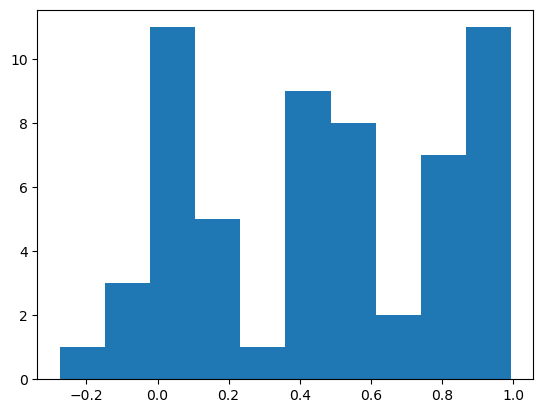

In [5]:
df_revaluation_data = pd.read_csv("NHB_2017_Exp1.csv")
df_revaluation_data
# compute subjectwise averages
df_subjectwise = {}
keys = df_revaluation_data['sub'].unique()
keys
for key in keys:
    df_subjectwise_data = df_revaluation_data['rs'][(df_revaluation_data['condition']=='transition') & (df_revaluation_data['sub']==key)]
    df_subjectwise[key] = df_subjectwise_data.mean()

df_subjectwise = pd.DataFrame.from_dict(df_subjectwise,orient='index')
plt.hist(df_subjectwise[0],bins=10)
range_hist = (np.min(df_subjectwise[0]),np.max(df_subjectwise[0]))

In [6]:
plt.rcParams.update({'font.size': 12}) 

# You can also set specific font sizes for different elements:
plt.rcParams['axes.titlesize'] = 14  # For plot titles
plt.rcParams['axes.labelsize'] = 12  # For axis labels
plt.rcParams['xtick.labelsize'] = 10 # For x-axis tick labels
plt.rcParams['ytick.labelsize'] = 10 # For y-axis tick labels
plt.rcParams['legend.fontsize'] = 10 # For legend text

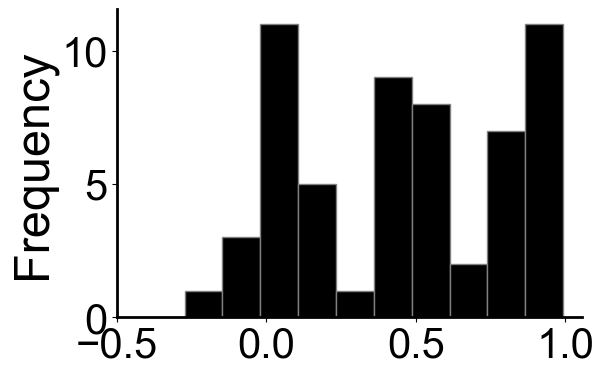

In [7]:

fig, ax = plt.subplots(figsize=(6, 4))
counts1, bins1, patches1 = plt.hist(df_subjectwise[0],  color="#000000",  edgecolor='grey')

mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
size1 = 30
size2 = 35
# plt.title('Human')
ax.set_xlabel('')
ax.set_ylabel('Frequency', fontsize=size2)
## change the size the ticks size
plt.tick_params(axis='both', which='major', labelsize=size1)
plt.tick_params(axis='both', which='minor', labelsize=size1)
# plt.grid(True)
sns.despine()
plt.xticks([-0.5, 0, 0.5, 1], rotation=0) 
ax.spines['bottom'].set_linewidth(2)  # Thicken the x-axis
ax.spines['left'].set_linewidth(2)    # Thicken the y-axis

plt.savefig('Figures/TransitionRevaluation_Human_SGM2025_2026.svg', format='svg', dpi=300, bbox_inches='tight')

## Defining transition lists

In [8]:
# transition_lists is a dict with the name of each phase and a data frame consisting of the transition list and whether or not that transition was the last one in a trial or not
learning_frame = pd.DataFrame(columns=['transition', 'trial_end'])
n_episodes = 20
# column names: transition, trial_end

for i in range(n_episodes):
    learning_frame.loc[4*i] = [[1,3], 0]
    learning_frame.loc[4*i+1] = [[3,5], 0]
    learning_frame.loc[4*i+2] = [[0,2], 0]
    learning_frame.loc[4*i+3] = [[2,4], 1]

relearning_frame = pd.DataFrame(columns=['transition', 'trial_end'])
n_episodes = 20
# column names: transition, trial_end
for i in range(n_episodes):
    relearning_frame.loc[2*i] = [[3,4], 0]
    relearning_frame.loc[2*i+1] = [[2,5], 1]

# combine the two dataframes into a dict
transition_lists = {'learning': learning_frame, 'relearning': relearning_frame}

# define states positions for graph figure
states =  ['A','B','C','D','E','F']
pos = {'A': (0,1), 'B': (0,0), 'C': (1,1), 'D': (1,0), 'E': (2,1), 'F': (2,0)}

# Phase diagram (transition reevaluation)

/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/CodeBase_git/Feb2026/Figure2 _StructureLearning/helper_functions_SR.py:193: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(x/(1-x))
/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_7159/2820061339.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors


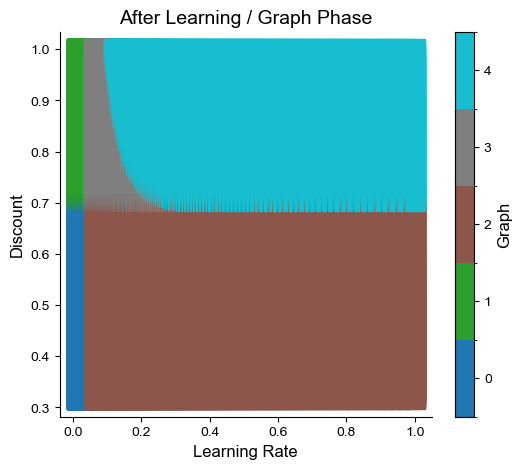

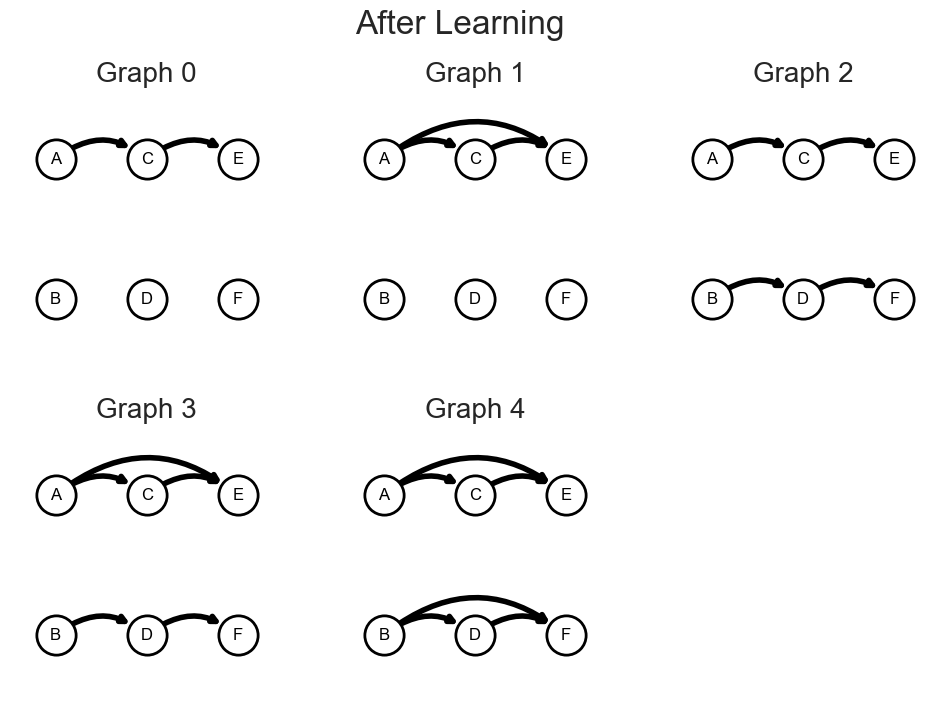

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_7159/2820061339.py:225: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors


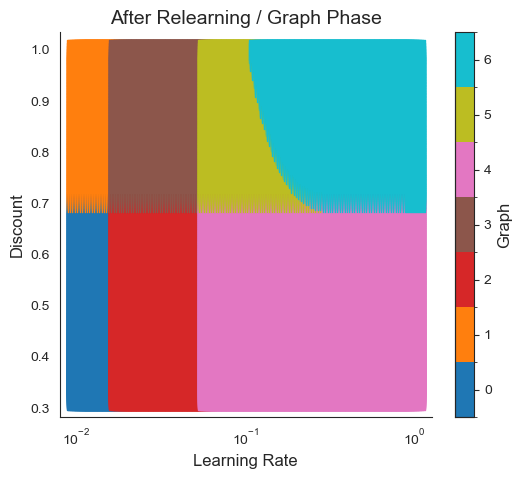

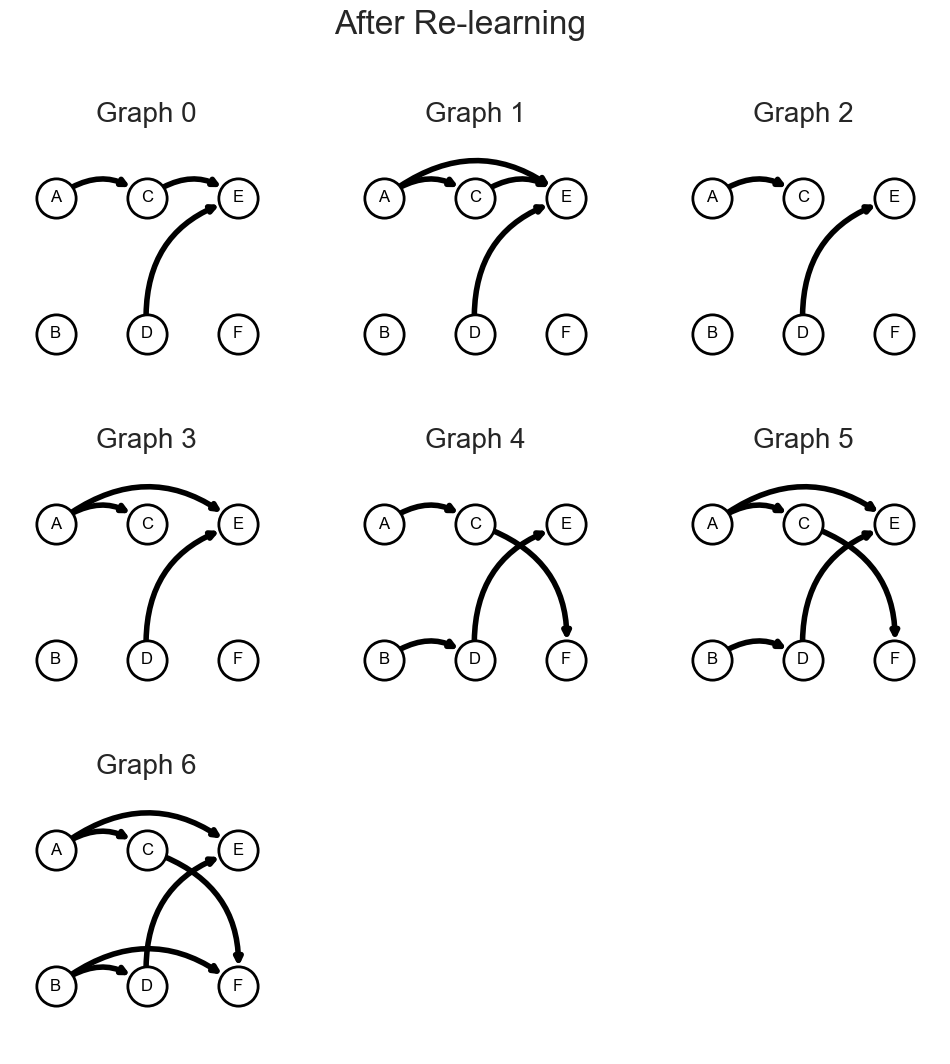

In [10]:

#vary the value of parameter learning rate and threshold

graph_iter = []
graph_iter_pre = []

iter_num = []

range_lr = np.logspace(-2, 0, 200)
range_dct = np.logspace(-0.5, 0, 200)

# range_dct = np.arange(0.01,0.99,0.01)

# for lr_i in np.logspace(-10, 0, 5):
# for lr_i in np.arange(0.01,1,0.05):

revaluation_scores = []
for lr_i in range_lr:

    for dct_i in range_dct:


        learning_rate = inv_logit(lr_i)
        threshold = inv_logit(0.70)
        discount = inv_logit(dct_i)
        # learning_rate_rew_stim = inv_logit(0.1)
        # learning_rate_norew_stim = inv_logit(0.1)
        learning_rate_rew_nostim = inv_logit(0.4)
        reward_learning_rate = inv_logit(0.9)


        n_runs = 1

        for i in range(n_runs):
            graph_list_learning, graph_list_relearning, rewards_list_learning, rewards_list_relearning, preference_after_learning, preference_after_relearning, revaluation_score, sr_list_learning, sr_list_relearning = learnCG_transitionRev(learning_rate, threshold, discount,learning_rate_rew_nostim,reward_learning_rate, transition_lists, n_episodes, add_noise = 0)
            revaluation_scores.append(revaluation_score)


        # Save SR_after_learning for case 1
        SR_after_learning = sr_list_learning[-1]
        SR_after_relearning = sr_list_relearning[-1]

        graph_after_learning = graph_list_learning[-1]
        graph_after_relearning = graph_list_relearning[-1]

        graph_iter.append(graph_after_relearning)
        graph_iter_pre.append(graph_after_learning)

        iter_num.append((lr_i,dct_i))


## generate histogram
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter]

# Count frequencies
counts = Counter(hashable_arrays)

# Prepare labels and values for histogram
labels = [str(np.array(k)) for k in counts.keys()]
values = list(counts.values())

# Plot
# plt.figure(figsize=(20, 6))
# plt.bar(range(len(values)), values, tick_label=labels)
# plt.ylabel("Frequency")
# plt.xticks(rotation=90, ha='right')
# plt.tight_layout()
# plt.show()


# revaluation_scores = -1*np.array(revaluation_scores)


####### ##############################################
# Generate plots for phase after learning
################ ############################## ##########################

###
## generate histogram
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter_pre]


# Count frequencies
counts = Counter(hashable_arrays)

# Build identity vector
ids = []
for mat in graph_iter_pre:
    for i, uniq in enumerate(list(counts.keys())):
        if np.array_equal(mat, uniq):   # compare matrices
            ids.append(i)  # or i+1 if you want 1-based index
            break

import matplotlib.pyplot as plt
import numpy as np

# Example data


x, y = zip(*iter_num)
x = np.array(x)
y = np.array(y)
ids = np.array(ids)

# Discrete colormap

### Generate plot for Graph phase diagram

unique_ids = np.unique(ids)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


plt.figure(figsize=(6, 5))
sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

cbar = plt.colorbar(sc, ticks=range(n_ids))
cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
cbar.set_label("Graph")

plt.xlabel("Learning Rate")
# plt.xscale("log")   # make y-axis logarithmic
plt.ylabel("Discount")
plt.title("After Learning / Graph Phase")

sns.set_style("white")
sns.despine()


plt.show()



n = len(counts)
ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
nrows = int(np.ceil(n / ncols))

array_unique = list(counts.keys())

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# Flatten axes for easy indexing
axes = axes.flatten()

for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

    mat = array_unique[iii]
    f = iii
    node_sizes = 800

    # plot the graph using nx.digraph
    G = nx.MultiDiGraph()
    G.add_nodes_from(states)
    connectionstyle1 = 'arc3,rad=-0.4'
    connectionstyle2 = 'arc3,rad=-0.4'
    edgelist1 = []
    edgelist2 = []
    for i in range(len(states)):
        for j in range(len(states)):
            if mat[i][j] == 1:
                edgelist1.append((states[i],states[j]))

    nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
    # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 1.5)

    # save figure to svg
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

    ax.set_title("Graph " + str(f), fontsize=20)
    
    #     Hide any unused subplots if counts doesn't fill the grid
    for ax in axes[n:]:
        ax.axis("off")

plt.suptitle("After Learning", fontsize=24)


plt.show()


####### ##############################################
# Generate plot for phase after relearning
################ ############################## ##########################

###
## generate histogram
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter]


# Count frequencies
counts = Counter(hashable_arrays)

# Build identity vector
ids = []
for mat in graph_iter:
    for i, uniq in enumerate(list(counts.keys())):
        if np.array_equal(mat, uniq):   # compare matrices
            ids.append(i)  # or i+1 if you want 1-based index
            break

import matplotlib.pyplot as plt
import numpy as np

# Example data


x, y = zip(*iter_num)
x = np.array(x)
y = np.array(y)
ids = np.array(ids)

# Discrete colormap

### Generate plot for Graph phase diagram

unique_ids = np.unique(ids)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


plt.figure(figsize=(6, 5))
sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

cbar = plt.colorbar(sc, ticks=range(n_ids))
cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
cbar.set_label("Graph")

plt.xlabel("Learning Rate")
plt.xscale("log")   # make y-axis logarithmic
plt.ylabel("Discount")
plt.title("After Relearning / Graph Phase")

sns.set_style("white")
sns.despine()


plt.show()



n = len(counts)
ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
nrows = int(np.ceil(n / ncols))

array_unique = list(counts.keys())

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# Flatten axes for easy indexing
axes = axes.flatten()

for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

    mat = array_unique[iii]
    f = iii
    node_sizes = 800

    # plot the graph using nx.digraph
    G = nx.MultiDiGraph()
    G.add_nodes_from(states)
    connectionstyle1 = 'arc3,rad=-0.4'
    connectionstyle2 = 'arc3,rad=-0.4'
    edgelist1 = []
    edgelist2 = []
    for i in range(len(states)):
        for j in range(len(states)):
            if mat[i][j] == 1:
                edgelist1.append((states[i],states[j]))

    nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
    # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 1.5)

    # save figure to svg
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

    ax.set_title("Graph " + str(f), fontsize=20)
    
    #     Hide any unused subplots if counts doesn't fill the grid
    for ax in axes[n:]:
        ax.axis("off")

plt.suptitle("After Re-learning", fontsize=24)
plt.show()



/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_7159/1146321612.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors


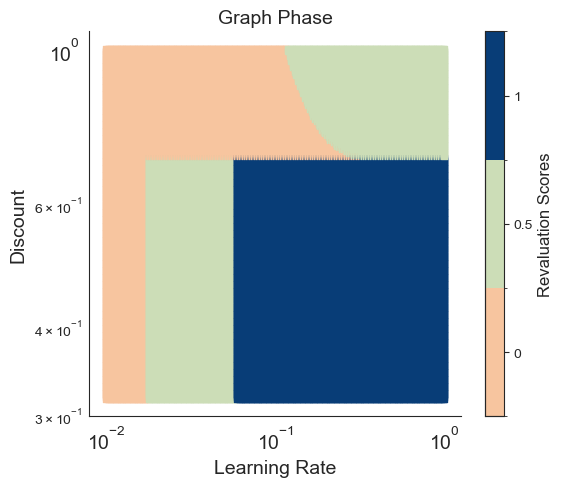

In [11]:

####### ##############################################
# Generate plot for Modes of Revaluation Scores
################ ############################## ##########################
# Discrete colormap

fontSizeSelect = 14
revaluation_scores = np.array(revaluation_scores)
bins = 3   # number of bins

labels = np.digitize(revaluation_scores, bins=np.linspace(revaluation_scores.min(), revaluation_scores.max(), bins+1)[1:-1])
# labels = revaluation_scores

unique_ids = np.unique(labels)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


custom_colors = ['#F7C59F', '#CCDDB7', '#083D77']  # custom colors for 3 bins
cmap = mcolors.ListedColormap(custom_colors)  
plt.figure(figsize=(6, 5))
sc = plt.scatter(x, y, c=labels, cmap=cmap, s=20, marker="s", norm=norm)  # square markers = pixels

cbar = plt.colorbar(sc, ticks=range(n_ids))
cbar.ax.set_yticklabels([0, 0.5, 1])  # replace [0,1,2] with custom labels
# cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
cbar.set_label("Revaluation Scores")

plt.xlabel("Learning Rate", fontsize=fontSizeSelect)

plt.xscale("log")   # make y-axis logarithmic
plt.yscale("log")   # make y-axis logarithmic


plt.ylabel("Discount", fontsize=fontSizeSelect)
plt.title("Graph Phase", fontsize=fontSizeSelect)

# ticks font size
plt.xticks(fontsize=fontSizeSelect)
plt.yticks(fontsize=fontSizeSelect)

sns.set_style("white")
sns.despine()


# add circle with centered at mean = [0.26, 0.75] and radius = 0.1
# mean_lr = 0.26
# mean_dct = 0.75
# radius = 0.1
# circle = plt.Circle((mean_lr, mean_dct), radius, color='yellow', fill=False, linewidth=2)
# plt.gca().add_patch(circle)

# savefigure to svg
plt.savefig('Figures/SGM2025_TransitionRevaluation_GraphPhase_RevaluationScores_2026.svg', format='svg', bbox_inches='tight')

plt.show()

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_7159/2453311899.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors


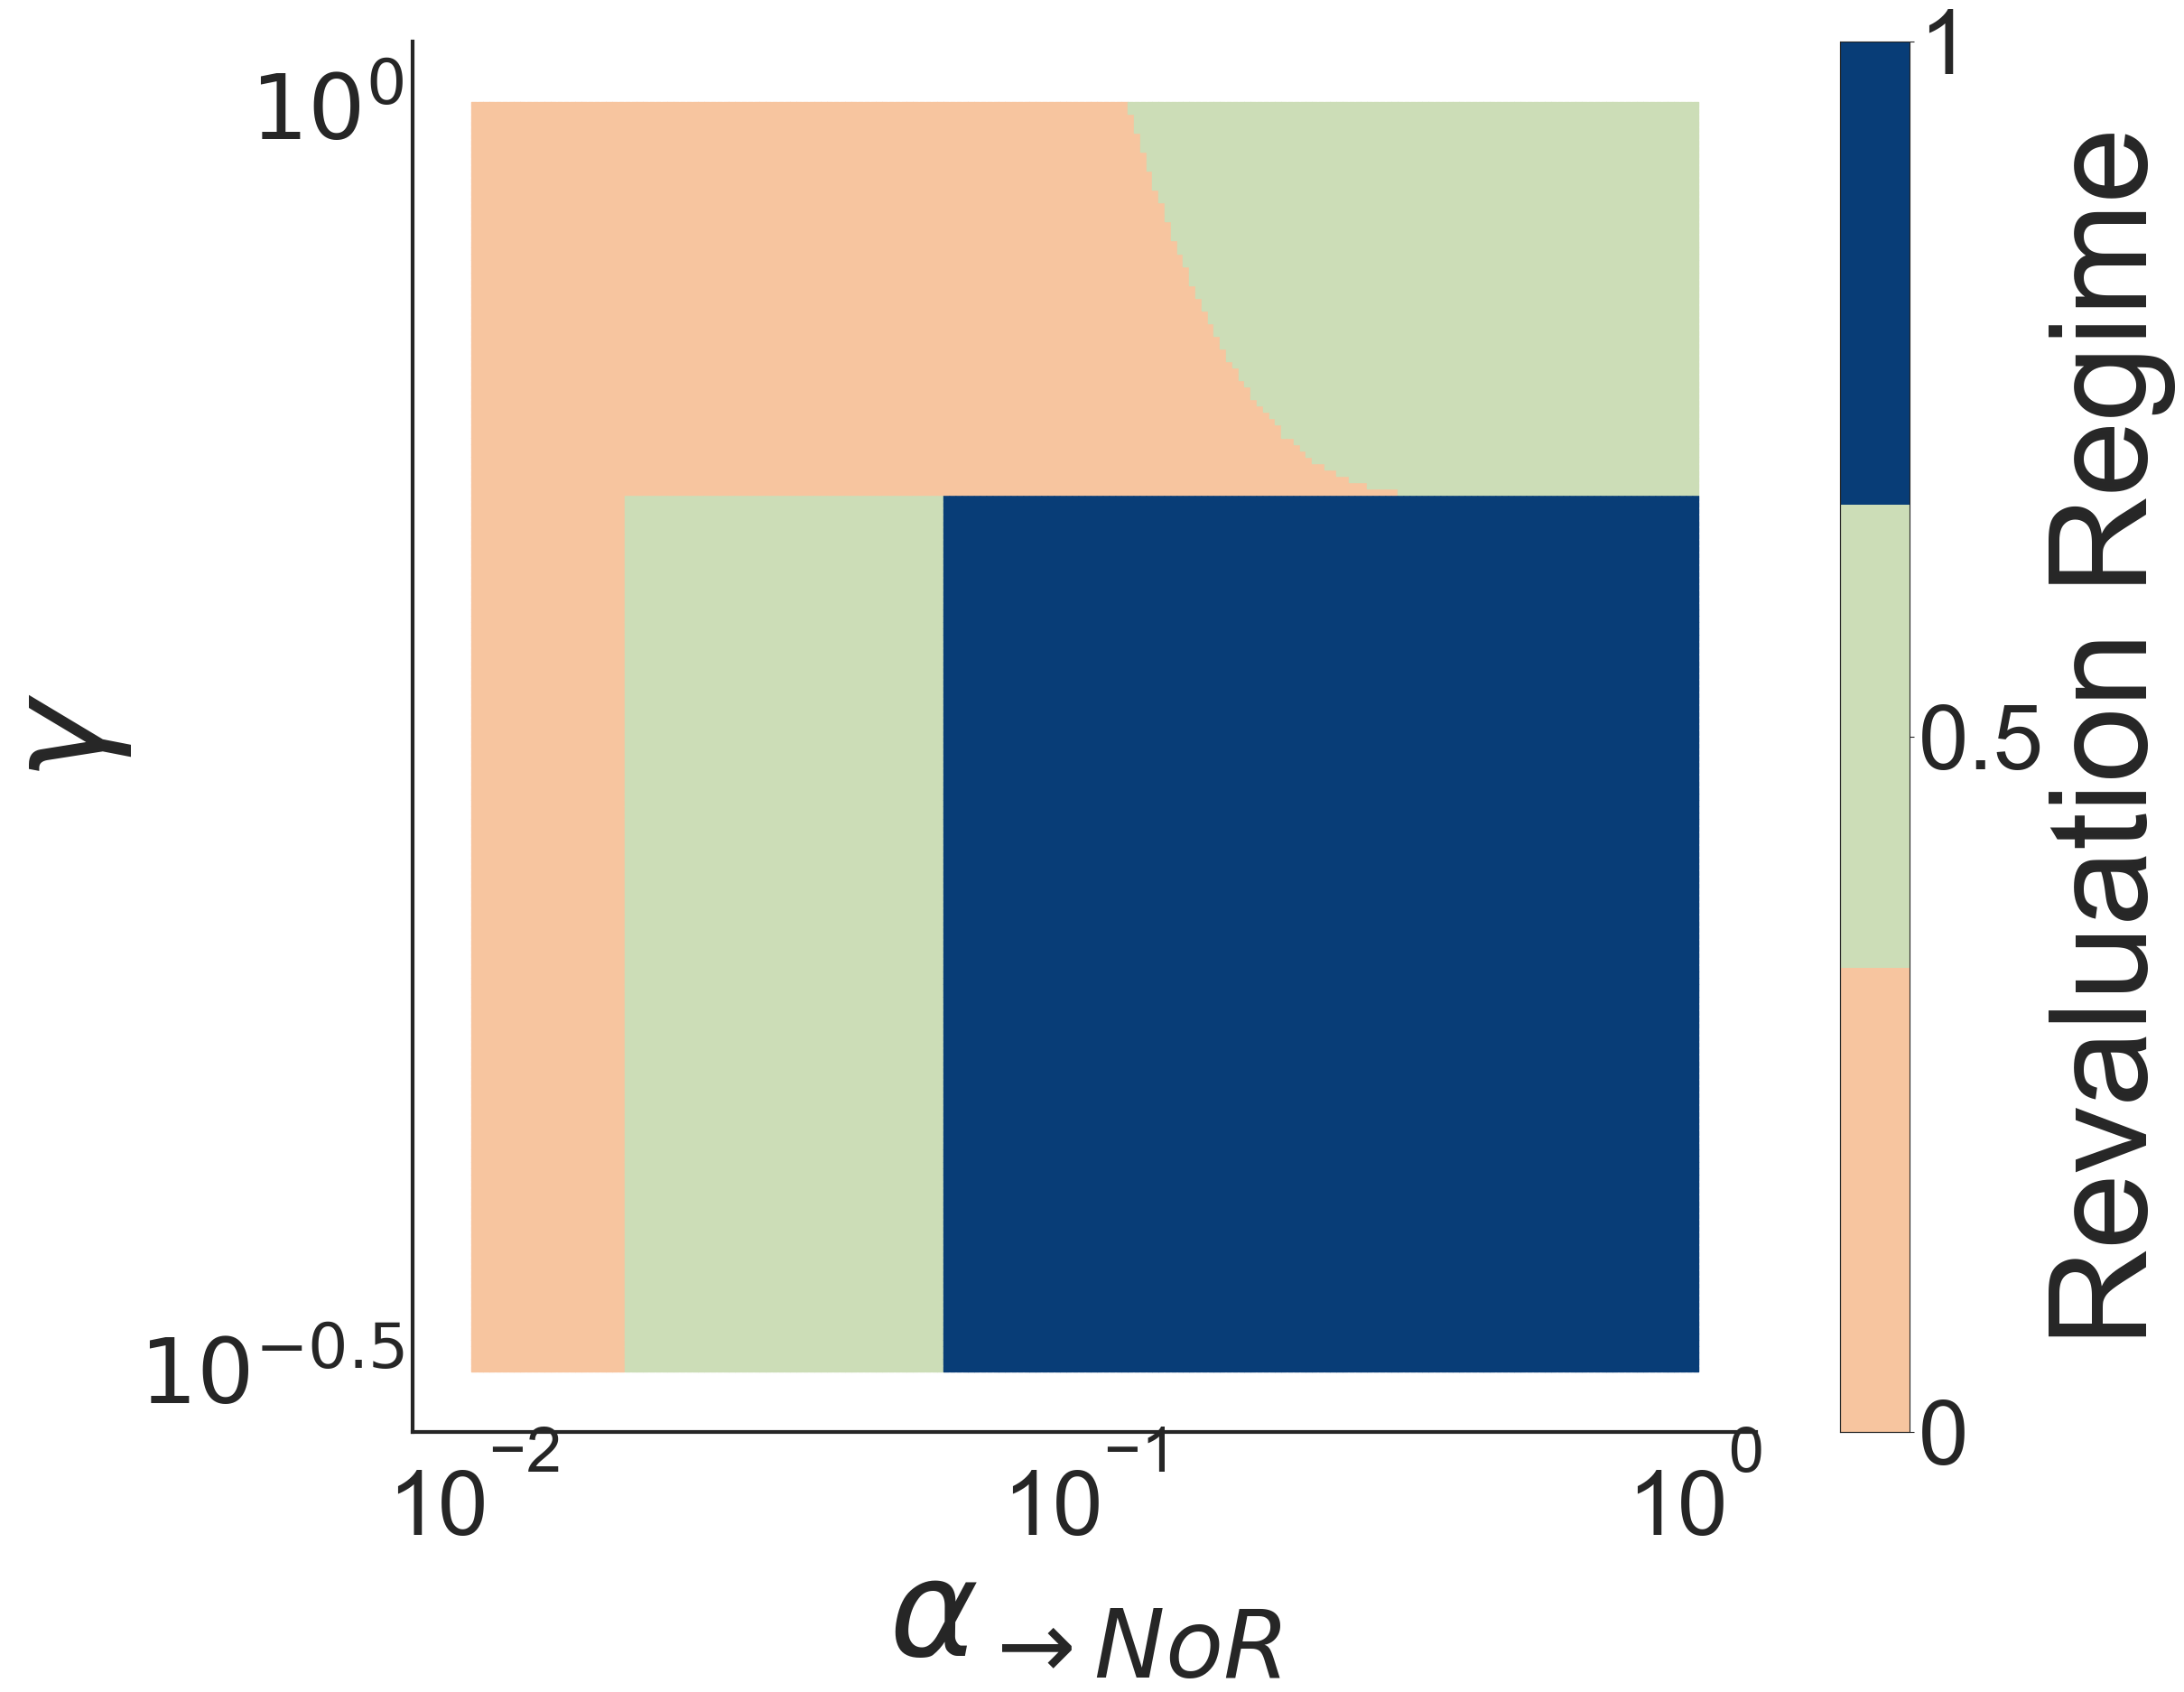

In [12]:

mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

nn = 4

fontSizeSelect = 30 *nn*3/5

bins = 3   # number of bins

fig, ax = plt.subplots(figsize=(6*nn, 5*nn))  # define figure and axis

labels = np.digitize(revaluation_scores, bins=np.linspace(revaluation_scores.min(), revaluation_scores.max(), bins+1)[1:-1])


unique_ids = np.unique(labels)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


custom_colors = ['#F7C59F', '#CCDDB7', '#083D77']  # custom colors for 3 bins
cmap = mcolors.ListedColormap(custom_colors)  

sc = plt.scatter(x, y, c=labels, cmap=cmap, s=20, marker="s")  # square markers = pixels

cbar = plt.colorbar(sc, ticks=range(n_ids))
cbar.ax.set_yticklabels([0, 0.5, 1], fontsize=fontSizeSelect)  # replace [0,1,2] with custom labels
# cbar.ax.set_yticklabels(unique_ids)  # show actual idsxcvxcvxcvxcvxv instead of 0,1,2...
cbar.set_label("Revaluation Regime", fontsize=fontSizeSelect*1.5)


plt.xlabel(r'$\alpha_{\rightarrow NoR}$', fontsize=fontSizeSelect*1.5)

plt.xscale("log")   # make y-axis logarithmic
plt.yscale("log")   # make y-axis logarithmic

from matplotlib.ticker import FixedLocator

# Force EXACT y ticks only at 10^0 and 10^-0.5
ax.yaxis.set_major_locator(FixedLocator([10**0, 10**(-0.5)]))
ax.yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks
ax.set_yticklabels(["$10^{0}$", "$10^{-0.5}$"], fontsize=fontSizeSelect)

plt.ylabel(r'$\gamma$', fontsize=fontSizeSelect*1.5)
# plt.title("Graph Phase", fontsize=fontSizeSelect)

# ticks font size
plt.xticks(fontsize=fontSizeSelect)
plt.yticks( fontsize=fontSizeSelect)

ax.tick_params(axis='both', which='major', labelsize=fontSizeSelect)
ax.tick_params(axis='both', which='minor', labelsize=fontSizeSelect )


sns.set_style("white")
sns.despine()


ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
# savefigure to svg
plt.savefig('Figures/SGM2025_TransitionRevaluation_GraphPhase_RevaluationScores_2026.svg', format='svg', bbox_inches='tight')

plt.show()

In [ ]:
x_phaseD = x.copy()
y_phaseD = y.copy()
labels_phaseD = labels.copy()


# Show triple point in the phase diagram

In [14]:
# import numpy as np
# from scipy.spatial import cKDTree

# # Suppose you already have:
# # x, y = coordinate arrays (same length)
# # labels = discrete phase labels (0, 1, 2)

# points = np.column_stack((x, y))
# tree = cKDTree(points)

# # Radius for neighborhood search (tune this)
# radius = 0.005

# triple_indices = []
# triple_parameters = []
# for i, label in enumerate(labels):
#     # find neighbors within radius
#     neighbors = tree.query_ball_point(points[i], r=radius)
#     neighbor_labels = np.unique(labels[neighbors])
    
#     # triple point condition: all 3 labels appear nearby
#     if len(neighbor_labels) == 3:
#         triple_indices.append(i)
#         triple_parameters.append((x[i], y[i]))

# triple_coords = points[triple_indices]
# print("Triple point coordinates (Learning Rate, Discount):")


# plt.scatter(x, y, c=labels, cmap=cmap, s=200, marker="s")
# plt.scatter(triple_coords[:,0], triple_coords[:,1], color="black", s=100, marker="x")
# # log scale for axes
# # plt.xscale("log")
# plt.ylabel("Discount")
# plt.xlabel("Learning Rate")


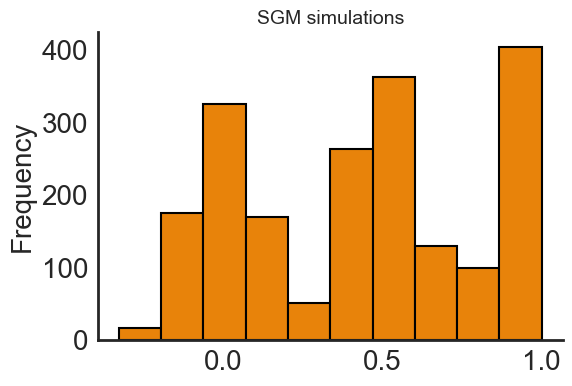

In [15]:

graph_iter = []
iter_num = []   


revaluation_scores_distribution = []
graph_iter_after_learning = []


# Parameters

# picked based on previous simulations
mean = [0.042 ,0.68]                 # mean vector
cov = [[.001, 0], [0, .001]]         # covariance matrix (correlation = 0.8)

params_samples = []

for i in range(2000):
    lr_x = -1
    dct_y = -1
    while (lr_x<0 or lr_x>1 ) or (dct_y < 0  or dct_y > 1):
        samples = np.random.multivariate_normal(mean, cov, size=1)
        # Extract columns
        lr_x, dct_y = samples[0][0], samples[0][1]


    learning_rate = inv_logit(lr_x)
    threshold = inv_logit(0.70)
    discount = inv_logit(dct_y)
    learning_rate_rew_nostim = inv_logit(0.4)
    reward_learning_rate = inv_logit(0.9)
    
    
    n_runs = 1
    for i in range(n_runs):
        # generate random value for scaling factor between 0.000001 and 0.01
        graph_list_learning, graph_list_relearning, rewards_list_learning, rewards_list_relearning, preference_after_learning, preference_after_relearning, revaluation_score, sr_list_learning, sr_list_relearning = learnCG_transitionRev(learning_rate, threshold, discount,learning_rate_rew_nostim,reward_learning_rate, transition_lists, n_episodes, add_noise = 0.1)


    # Save SR_after_learning for case 1
    SR_after_learning = sr_list_learning[-1]
    SR_after_relearning = sr_list_relearning[-1]

    graph_after_learning = graph_list_learning[-1]
    graph_after_relearning = graph_list_relearning[-1]

    # revaluation_scores = np.array(revaluation_scores)
    revaluation_scores_distribution.append(revaluation_score)

    params_samples.append([lr_x,dct_y])
    graph_iter.append(graph_after_relearning)
    graph_iter_after_learning.append(graph_after_learning)


labels = np.digitize(revaluation_scores_distribution, bins=np.linspace(np.min(revaluation_scores_distribution), np.max(revaluation_scores_distribution), 3+1)[1:-1])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(revaluation_scores_distribution, color="#e8830a",  edgecolor='black', linewidth=1.5)
ax.set_title('SGM simulations')
ax.set_xlabel('')
ax.set_ylabel('Frequency', fontsize=20)
## change the size the ticks size
plt.tick_params(axis='both', which='major', labelsize=20)
plt.tick_params(axis='both', which='minor', labelsize=20)
# plt.grid(True)
sns.despine()
# plt.xticks([-0.5, 0, 0.5, 1], rotation=0) 
ax.spines['bottom'].set_linewidth(2)  # Thicken the x-axis
ax.spines['left'].set_linewidth(2)    # Thicken the y-axis
# save svg figure
# plt.savefig('Figures/TransitionRevaluation_Sims_sampleSingleDistribution_SGM2025_2026.svg', format='svg', dpi=300, bbox_inches='tight')



In [16]:

# bin values of reevaluation_scores_distribution <0.25, 0.25<x<0.75, >0.75
bins_figure = [-1, 0.25, 0.75, 1.2]
labels_reev= np.digitize(revaluation_scores_distribution, bins=bins_figure)
# 


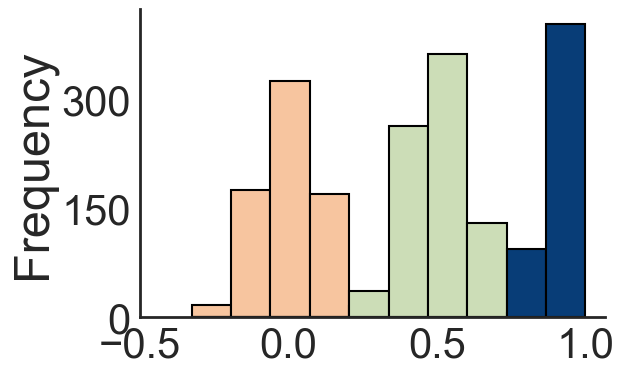

In [17]:
import matplotlib.ticker as ticker
custom_colors = ['#F7C59F', '#CCDDB7', '#083D77']  # custom colors for 3 bins
mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
size1 = 30
size2 = 35

binsStd = np.histogram(revaluation_scores_distribution, bins=10)[1]

fig, ax = plt.subplots(figsize=(6, 4))

# if revaluation_scores > 1, set to 1
#revaluation_scores[revaluation_scores > 1] = 1
plt.hist(np.array(revaluation_scores_distribution)[labels_reev==1], bins = binsStd, range = range_hist, color = custom_colors[0], alpha = 1, label = 'Mode 1',edgecolor='black', linewidth=1.5)
plt.hist(np.array(revaluation_scores_distribution)[labels_reev==2], bins = binsStd, range = range_hist, color = custom_colors[1], alpha = 1, label = 'Mode 2',edgecolor='black', linewidth=1.5)
plt.hist(np.array(revaluation_scores_distribution)[labels_reev==3], bins = binsStd, range = range_hist, color = custom_colors[2], alpha = 1, label = 'Mode 3',edgecolor='black', linewidth=1.5)
plt.legend
# x-axis label: Revaluation Scores
# plt.xlabel('Revaluation Scores', fontsize=20)
# y-axis label: No. of participants
ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
plt.ylabel('Frequency', fontsize=size2)
# Title: Histogram of Revaluation Scores
# plt.title('Histogram of Revaluation Scores')

sns.despine()
plt.xticks([-0.5, 0, 0.5, 1], fontsize=size1, rotation=0) 
plt.yticks(fontsize=size1, rotation=0) 

ax.spines['bottom'].set_linewidth(2)  # Thicken the x-axis
ax.spines['left'].set_linewidth(2)    # Thicken the y-axis
# save svg figure
plt.savefig('Figures/TransitionRevaluation_Sims_sampleSingleDistribution_MultiColor_SGM2025_2026.svg', format='svg', dpi=300, bbox_inches='tight')


plt.show()

# Plot diagrams and graphs for sampled graphs

In [18]:
# # index where graph iters have nan values
# nan_indices = [i for i, g in enumerate(graph_iter) if np.isnan(g).any()]

# params_samples_selected = [p for i, p in enumerate(params_samples) if i not in nan_indices]
# graph_iter_selcted = [g for i, g in enumerate(graph_iter) if i not in nan_indices]


# hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter_selcted]


# # Count frequencies
# counts = Counter(hashable_arrays)

# # Build identity vector
# ids = []
# for mat in graph_iter:
#     for i, uniq in enumerate(list(counts.keys())):
#         if np.array_equal(mat, uniq):   # compare matrices
#             ids.append(i)  # or i+1 if you want 1-based index
#             break

# # Example data
# x, y = zip(*params_samples_selected)
# x = np.array(x)
# y = np.array(y)
# ids = np.array(ids)

# # Discrete colormap

# ### Generate plot for Graph phase diagram

# unique_ids = np.unique(ids)
# n_ids = len(unique_ids)

# cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
# norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


# plt.figure(figsize=(6, 5))
# sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

# cbar = plt.colorbar(sc, ticks=range(n_ids))
# cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
# cbar.set_label("Graph")

# plt.xlabel("Learning Rate")
# plt.xscale("log")   # make y-axis logarithmic
# plt.yscale("log")   # make y-axis logarithmic

# plt.ylabel("Discount")
# plt.title("Graph Phase after Relearning")

# sns.set_style("white")
# sns.despine()

# plt.show()


In [19]:

# n = len(counts)
# ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
# nrows = int(np.ceil(n / ncols))

# array_unique = list(counts.keys())

# fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# # Flatten axes for easy indexing
# axes = axes.flatten()

# for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

#     mat = array_unique[iii]
#     f = iii
#     node_sizes = 800

#     # plot the graph using nx.digraph
#     G = nx.MultiDiGraph()
#     G.add_nodes_from(states)
#     connectionstyle1 = 'arc3,rad=-0.4'
#     connectionstyle2 = 'arc3,rad=-0.4'
#     edgelist1 = []
#     edgelist2 = []
#     for i in range(len(states)):
#         for j in range(len(states)):
#             if mat[i][j] == 1:
#                 edgelist1.append((states[i],states[j]))

#     nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
#     # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


#     ax.set_xlim(-0.5, 2.5)
#     ax.set_ylim(-0.5, 1.5)

#     # save figure to svg
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

#     ax.set_title("Graph " + str(f), fontsize=20)
    
#     #     Hide any unused subplots if counts doesn't fill the grid
#     for ax in axes[n:]:
#         ax.axis("off")

# plt.suptitle("After Re-learning", fontsize=24)
# plt.show()


In [20]:

# # index where graph iters have nan values
# nan_indices = [i for i, g in enumerate(graph_iter_after_learning) if np.isnan(g).any()]

# params_samples_selected = [p for i, p in enumerate(params_samples) if i not in nan_indices]
# graph_iter_selected = [g for i, g in enumerate(graph_iter_after_learning) if i not in nan_indices]


# hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter_selected]


# # Count frequencies
# counts = Counter(hashable_arrays)

# # Build identity vector
# ids = []
# for mat in graph_iter_after_learning:
#     for i, uniq in enumerate(list(counts.keys())):
#         if np.array_equal(mat, uniq):   # compare matrices
#             ids.append(i)  # or i+1 if you want 1-based index
#             break

# # Example data
# x, y = zip(*params_samples_selected)
# x = np.array(x)
# y = np.array(y)
# ids = np.array(ids)

# # Discrete colormap

# ### Generate plot for Graph phase diagram

# unique_ids = np.unique(ids)
# n_ids = len(unique_ids)

# cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
# norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


# plt.figure(figsize=(6, 5))
# sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

# cbar = plt.colorbar(sc, ticks=range(n_ids))
# cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
# cbar.set_label("Graph")

# plt.xlabel("Learning Rate")
# plt.xscale("log")   # make y-axis logarithmic
# plt.ylabel("Discount")
# plt.title("Graph Phase After Learning")

# sns.set_style("white")
# sns.despine()

# plt.show()


In [21]:

# n = len(counts)
# ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
# nrows = int(np.ceil(n / ncols))

# array_unique = list(counts.keys())

# fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# # Flatten axes for easy indexing
# axes = axes.flatten()

# for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

#     mat = array_unique[iii]
#     f = iii
#     node_sizes = 800

#     # plot the graph using nx.digraph
#     G = nx.MultiDiGraph()
#     G.add_nodes_from(states)
#     connectionstyle1 = 'arc3,rad=-0.4'
#     connectionstyle2 = 'arc3,rad=-0.4'
#     edgelist1 = []
#     edgelist2 = []
#     for i in range(len(states)):
#         for j in range(len(states)):
#             if mat[i][j] == 1:
#                 edgelist1.append((states[i],states[j]))

#     nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
#     # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


#     ax.set_xlim(-0.5, 2.5)
#     ax.set_ylim(-0.5, 1.5)

#     # save figure to svg
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

#     ax.set_title("Graph " + str(f), fontsize=20)
    
#     #     Hide any unused subplots if counts doesn't fill the grid
#     for ax in axes[n:]:
#         ax.axis("off")

# plt.suptitle("After Learning", fontsize=24)
# plt.show()


---------

# Reward Revaluation

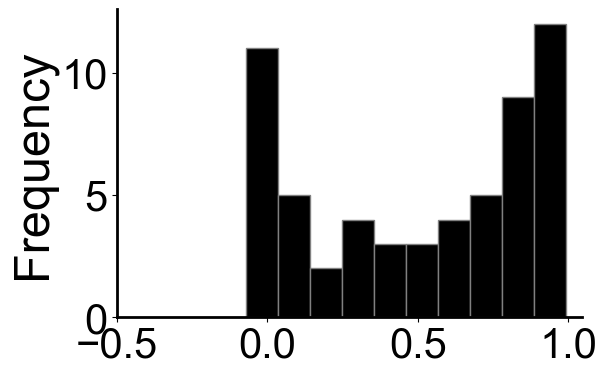

In [4]:
rewardReev_human_df = pd.read_csv('NHB_2017_Exp1.csv')


mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
size1 = 30
size2 = 35

reward_human_df = rewardReev_human_df.loc[rewardReev_human_df['condition'] == 'reward']

fig, ax = plt.subplots(figsize=(6, 4))
counts1, bins1, patches1 = plt.hist(reward_human_df.groupby('sub')['rs'].mean(),  color="#000000",  edgecolor='grey')
# plt.title('Human')
ax.set_xlabel('')
ax.set_ylabel('Frequency', fontsize=size2)
## change the size the ticks size
plt.tick_params(axis='both', which='major', labelsize=size1)
plt.tick_params(axis='both', which='minor', labelsize=size1)
# plt.grid(True)
sns.despine()
plt.xticks([-0.5, 0, 0.5, 1], rotation=0) 
ax.spines['bottom'].set_linewidth(2)  # Thicken the x-axis
ax.spines['left'].set_linewidth(2)    # Thicken the y-axis

plt.savefig('Figures/RewardRevaluation_Human_SGM2025_2026.svg', format='svg', dpi=300, bbox_inches='tight')


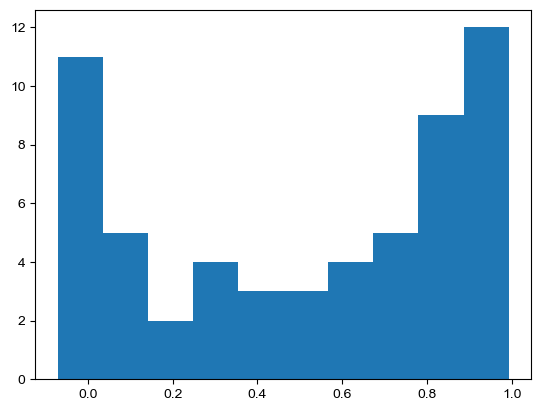

In [5]:
df_revaluation_data = pd.read_csv("NHB_2017_Exp1.csv")
df_revaluation_data
# compute subjectwise averages
df_subjectwise = {}
keys = df_revaluation_data['sub'].unique()
keys
for key in keys:
    df_subjectwise_data = df_revaluation_data['rs'][(df_revaluation_data['condition']=='reward') & (df_revaluation_data['sub']==key)]
    df_subjectwise[key] = df_subjectwise_data.mean()

df_subjectwise = pd.DataFrame.from_dict(df_subjectwise,orient='index')
plt.hist(df_subjectwise[0],bins=10)
range_hist = (np.min(df_subjectwise[0]),np.max(df_subjectwise[0]))

In [6]:
# transition_lists is a dict with the name of each phase and a data frame consisting of the transition list and whether or not that transition was the last one in a trial or not
learning_frame = pd.DataFrame(columns=['transition', 'trial_end'])
n_episodes = 20
# column names: transition, trial_end

for i in range(n_episodes):
        learning_frame.loc[4 * i]     = [[1, 3], 0]  # Left → Down
        learning_frame.loc[4 * i + 1] = [[3, 5], 0]  # Down → DownReward
        learning_frame.loc[4 * i + 2] = [[0, 2], 0]  # Right → Up
        learning_frame.loc[4 * i + 3] = [[2, 4], 1]  # Up → UpReward (end)

relearning_frame = pd.DataFrame(columns=['transition', 'trial_end'])
n_episodes = 20
# column names: transition, trial_end
for i in range(n_episodes):
        relearning_frame.loc[2 * i] = [[3, 5], 0]  # Down → DownReward
        relearning_frame.loc[2 * i + 1] = [[2, 4], 1]  # Up → UpReward (end)

# combine the two dataframes into a dict
transition_lists = {'learning': learning_frame, 'relearning': relearning_frame}


# define states positions for graph figure

states =  ['A','B','C','D','E','F']
pos = {'A': (0,1), 'B': (0,0), 'C': (1,1), 'D': (1,0), 'E': (2,1), 'F': (2,0)}

In [7]:
# Refactor the learnCG_transitionRev function to be better and use a sequence of transitions instead of repeating code
def learnCG_rewardRev(learning_rate_transformed, threshold_transformed, discount_transformed, learning_rate_rew_nostim_transformed,reward_learning_rate_transformed, transition_lists, n_episodes=20, added_noise = 1):
    learning_rate = 1/(1 + np.exp(-learning_rate_transformed))
    threshold = 1/(1 + np.exp(-threshold_transformed))
    discount = 1/(1 + np.exp(-discount_transformed))
    learning_rate_rew_nostim = 1/(1 + np.exp(-learning_rate_rew_nostim_transformed))
    reward_learning_rate = 1/(1 + np.exp(-reward_learning_rate_transformed))
    states = [0,1,2,3,4,5]

    terminal_states = [4,5]
    successor_representation = np.zeros((len(states),len(states)))
    thresholded_successor = np.zeros((len(states),len(states)))
    thresholded_successor_list = []
    values_list = []
    rewards_list_learning = []
    rewards_list_relearning = []
    sr_list_learning = [] 
    sr_list_relearning = []
    graph_list_learning = []
    graph_list_relearning = []
    learned_rewards = np.zeros(len(states))
    # transition_lists is a dict with the name of each phase and the transition matrix for that phase
    # print the first phase name
    for i in range(len(transition_lists)):
        # print('Phase ' +str(i+1) + ':', list(transition_lists.keys())[i])
        transition_frame = transition_lists[list(transition_lists.keys())[i]]

        if list(transition_lists.keys())[i] == 'learning':
                given_rewards = [0,0,0,0,10,1]
                # print('Given rewards during learning:', given_rewards)

        elif list(transition_lists.keys())[i] == 'relearning':
                given_rewards = [0,0,0,0,1,10]
                # print('Given rewards during relearning:', given_rewards)

        transition_list = transition_frame['transition'].tolist()
        trial_ends =    transition_frame['trial_end'].tolist()
        # loop through the transition list
        for transition in transition_list:
            current_state = transition[0]
            next_state = transition[1]
            current_state_index = states.index(current_state)
            next_state_index = states.index(next_state)
            learned_rewards[next_state_index] = learned_rewards[next_state_index]*(1 - reward_learning_rate) + reward_learning_rate*given_rewards[next_state_index]
            # value modulated learning rate
            values = get_values_from_graph_2(learned_rewards,thresholded_successor)


            if values[next_state_index] > np.max(given_rewards) / 2:  # if the value of the next state is high
                lr = learning_rate_rew_nostim
            else:
                lr = learning_rate


            # update the successor representation
            td_error = np.eye(len(states))[next_state_index,:] - successor_representation[current_state_index,:] + discount * successor_representation[next_state_index,:]
            successor_representation[current_state_index,:] = successor_representation[current_state_index,:] + lr * td_error
            #threshold the successor representation
            k = transition_list.index(transition)
            if trial_ends[k] == 1:
                thresholded_successor = successor_representation.copy()
                thresholded_successor[thresholded_successor < threshold] = 0
                thresholded_successor[thresholded_successor >= threshold] = 1
    
                if i == 0:
                    graph_list_learning.append(thresholded_successor.copy())
                    rewards_list_learning.append(learned_rewards.copy())
                    sr_list_learning.append(successor_representation.copy())
                else:
                    graph_list_relearning.append(thresholded_successor.copy())
                    rewards_list_relearning.append(learned_rewards.copy())
                    sr_list_relearning.append(successor_representation.copy())

    values_after_learning = get_values_from_graph_2(rewards_list_learning[-1],graph_list_learning[-1])

    preference_after_learning = erf_function(values_after_learning[0], values_after_learning[1],scale)

    values_after_relearning = get_values_from_graph_2(rewards_list_relearning[-1],graph_list_relearning[-1])
    
    preference_after_relearning = erf_function(values_after_relearning[0], values_after_relearning[1],scale) 


    # revaluation score
    revaluation_score_no_noise = preference_after_relearning - preference_after_learning
    # get sign of revaluation score
    if added_noise > 0:

        noiseIn = added_noise
        # print('Added noise to revaluation score: ', noiseIn)
        revaluation_score = np.random.normal(revaluation_score_no_noise, noiseIn)
        if revaluation_score > 1:
            revaluation_score = 1- (revaluation_score -1)
        if revaluation_score < 0:
            revaluation_score =  -1*revaluation_score


    else:
        revaluation_score = revaluation_score_no_noise

    return graph_list_learning, graph_list_relearning, rewards_list_learning, rewards_list_relearning, preference_after_learning, preference_after_relearning, revaluation_score, sr_list_learning, sr_list_relearning          

/Users/pradyumnasepulveda/Documents/Gits/SparseCognitiveGraph_2026/Figure2 _StructureLearning/helper_functions_SR.py:193: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(x/(1-x))


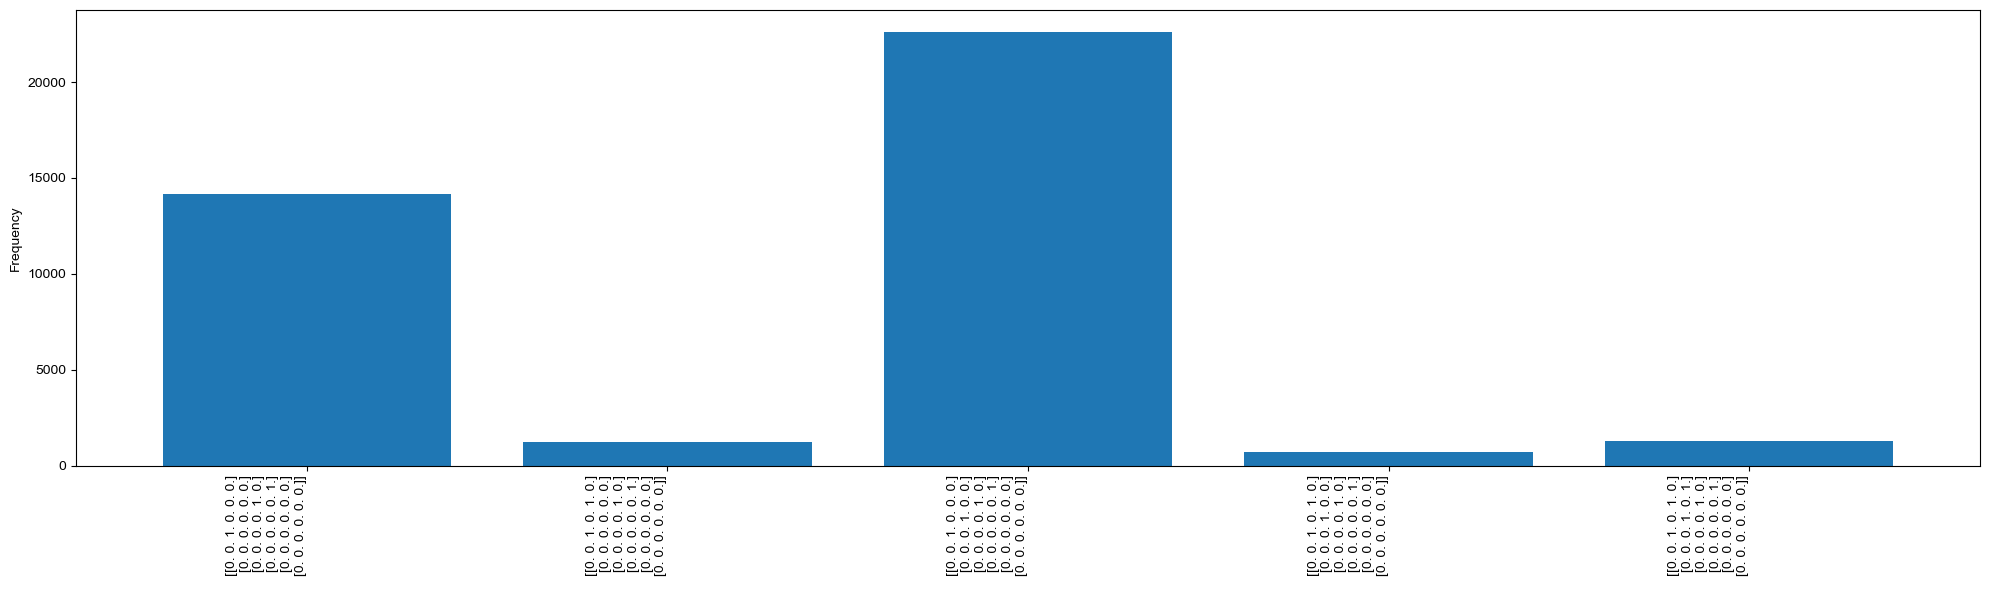

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_29033/3991440956.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors


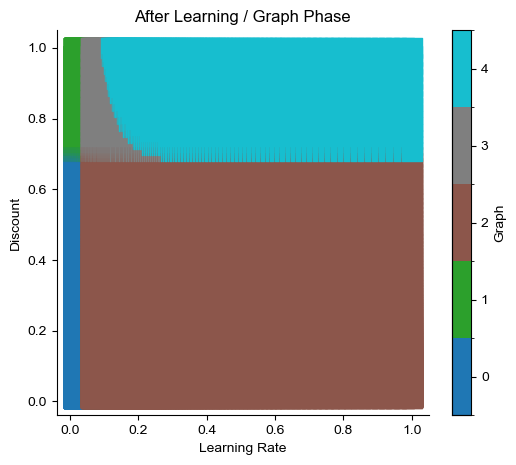

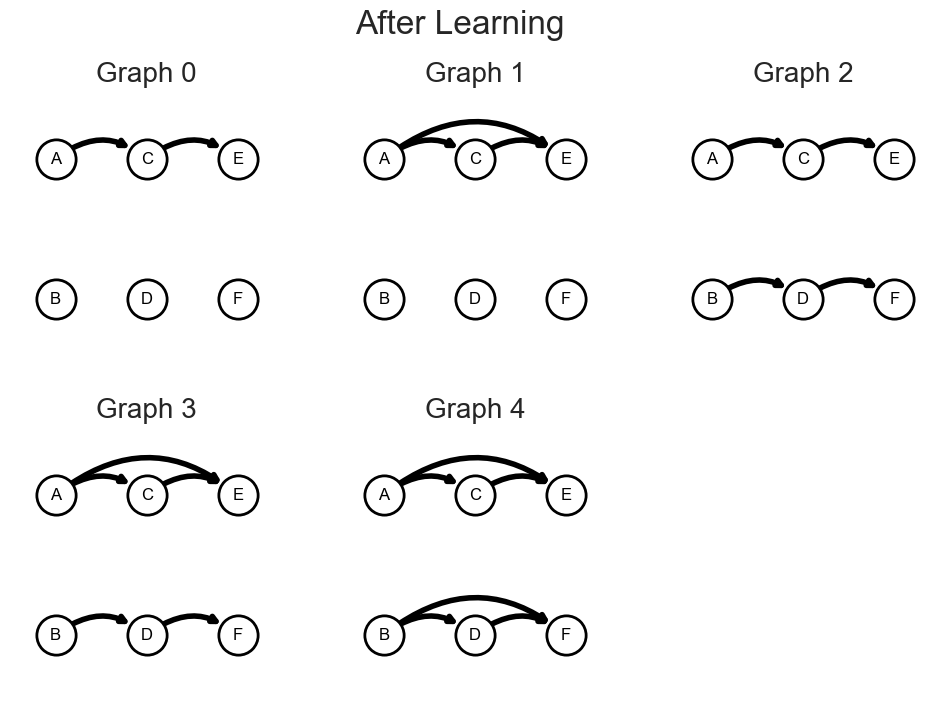

/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_29033/3991440956.py:225: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors


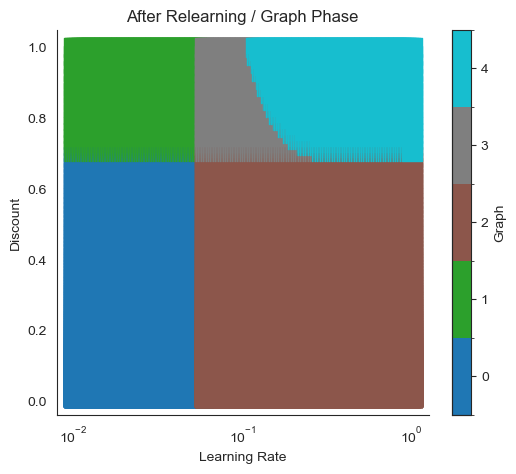

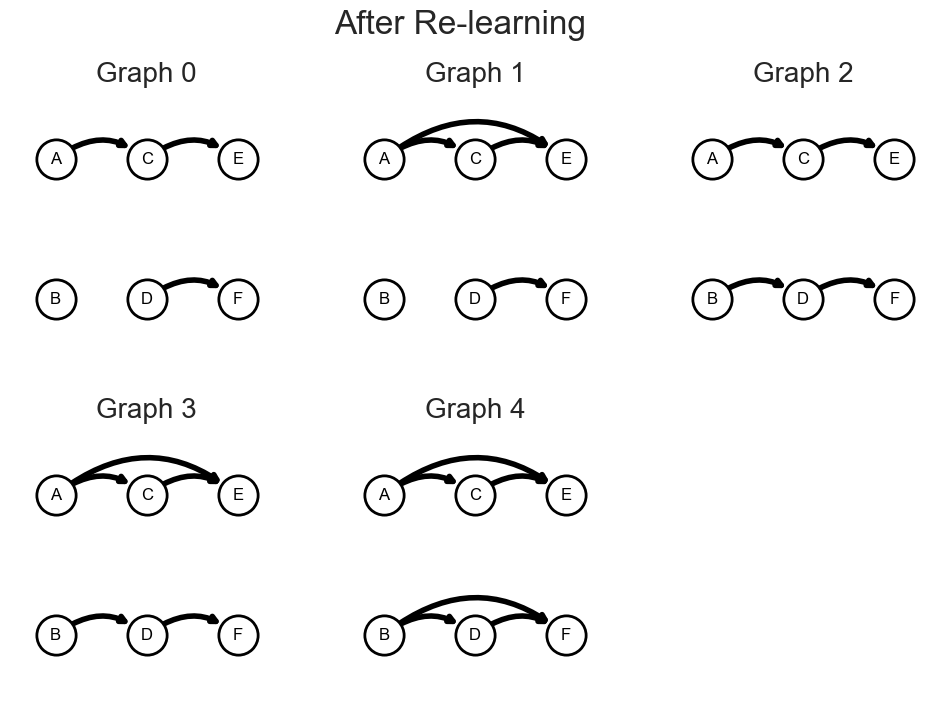

In [8]:

#vary the value of parameter learning rate and threshold

graph_iter = []
graph_iter_pre = []

iter_num = []

range_lr = np.logspace(-2, 0, 200)
range_dct = np.logspace(-2, 0, 200)

# range_dct = np.arange(0.01,0.99,0.01)

# for lr_i in np.logspace(-10, 0, 5):
# for lr_i in np.arange(0.01,1,0.05):

revaluation_scores = []
for lr_i in range_lr:

    for dct_i in range_dct:


        learning_rate = inv_logit(lr_i)
        threshold = inv_logit(0.70)
        discount = inv_logit(dct_i)
        # learning_rate_rew_stim = inv_logit(0.1)
        # learning_rate_norew_stim = inv_logit(0.1)
        learning_rate_rew_nostim = inv_logit(0.4)
        reward_learning_rate = inv_logit(0.9)


        n_runs = 1

        for i in range(n_runs):
            graph_list_learning, graph_list_relearning, rewards_list_learning, rewards_list_relearning, preference_after_learning, preference_after_relearning, revaluation_score, sr_list_learning, sr_list_relearning = learnCG_rewardRev(learning_rate, threshold, discount,learning_rate_rew_nostim,reward_learning_rate, transition_lists, n_episodes, added_noise = 0)
            revaluation_scores.append(revaluation_score)


        # Save SR_after_learning for case 1
        SR_after_learning = sr_list_learning[-1]
        SR_after_relearning = sr_list_relearning[-1]

        graph_after_learning = graph_list_learning[-1]
        graph_after_relearning = graph_list_relearning[-1]

        graph_iter.append(graph_after_relearning)
        graph_iter_pre.append(graph_after_learning)

        iter_num.append((lr_i,dct_i))


## generate histogram
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter]

# Count frequencies
counts = Counter(hashable_arrays)

# Prepare labels and values for histogram
labels = [str(np.array(k)) for k in counts.keys()]
values = list(counts.values())

# Plot
plt.figure(figsize=(20, 6))
plt.bar(range(len(values)), values, tick_label=labels)
plt.ylabel("Frequency")
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()


# revaluation_scores = -1*np.array(revaluation_scores)


####### ##############################################
# Generate plots for phase after learning
################ ############################## ##########################

###
## generate histogram
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter_pre]


# Count frequencies
counts = Counter(hashable_arrays)

# Build identity vector
ids = []
for mat in graph_iter_pre:
    for i, uniq in enumerate(list(counts.keys())):
        if np.array_equal(mat, uniq):   # compare matrices
            ids.append(i)  # or i+1 if you want 1-based index
            break

import matplotlib.pyplot as plt
import numpy as np

# Example data


x, y = zip(*iter_num)
x = np.array(x)
y = np.array(y)
ids = np.array(ids)

# Discrete colormap

### Generate plot for Graph phase diagram

unique_ids = np.unique(ids)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


plt.figure(figsize=(6, 5))
sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

cbar = plt.colorbar(sc, ticks=range(n_ids))
cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
cbar.set_label("Graph")

plt.xlabel("Learning Rate")
# plt.xscale("log")   # make y-axis logarithmic
plt.ylabel("Discount")
plt.title("After Learning / Graph Phase")

sns.set_style("white")
sns.despine()


plt.show()



n = len(counts)
ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
nrows = int(np.ceil(n / ncols))

array_unique = list(counts.keys())

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# Flatten axes for easy indexing
axes = axes.flatten()

for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

    mat = array_unique[iii]
    f = iii
    node_sizes = 800

    # plot the graph using nx.digraph
    G = nx.MultiDiGraph()
    G.add_nodes_from(states)
    connectionstyle1 = 'arc3,rad=-0.4'
    connectionstyle2 = 'arc3,rad=-0.4'
    edgelist1 = []
    edgelist2 = []
    for i in range(len(states)):
        for j in range(len(states)):
            if mat[i][j] == 1:
                edgelist1.append((states[i],states[j]))

    nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
    # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 1.5)

    # save figure to svg
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

    ax.set_title("Graph " + str(f), fontsize=20)
    
    #     Hide any unused subplots if counts doesn't fill the grid
    for ax in axes[n:]:
        ax.axis("off")

plt.suptitle("After Learning", fontsize=24)


plt.show()


####### ##############################################
# Generate plot for phase after relearning
################ ############################## ##########################

###
## generate histogram
hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter]


# Count frequencies
counts = Counter(hashable_arrays)

# Build identity vector
ids = []
for mat in graph_iter:
    for i, uniq in enumerate(list(counts.keys())):
        if np.array_equal(mat, uniq):   # compare matrices
            ids.append(i)  # or i+1 if you want 1-based index
            break

import matplotlib.pyplot as plt
import numpy as np

# Example data


x, y = zip(*iter_num)
x = np.array(x)
y = np.array(y)
ids = np.array(ids)

# Discrete colormap

### Generate plot for Graph phase diagram

unique_ids = np.unique(ids)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


plt.figure(figsize=(6, 5))
sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

cbar = plt.colorbar(sc, ticks=range(n_ids))
cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
cbar.set_label("Graph")

plt.xlabel("Learning Rate")
plt.xscale("log")   # make y-axis logarithmic
plt.ylabel("Discount")
plt.title("After Relearning / Graph Phase")

sns.set_style("white")
sns.despine()


plt.show()



n = len(counts)
ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
nrows = int(np.ceil(n / ncols))

array_unique = list(counts.keys())

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# Flatten axes for easy indexing
axes = axes.flatten()

for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

    mat = array_unique[iii]
    f = iii
    node_sizes = 800

    # plot the graph using nx.digraph
    G = nx.MultiDiGraph()
    G.add_nodes_from(states)
    connectionstyle1 = 'arc3,rad=-0.4'
    connectionstyle2 = 'arc3,rad=-0.4'
    edgelist1 = []
    edgelist2 = []
    for i in range(len(states)):
        for j in range(len(states)):
            if mat[i][j] == 1:
                edgelist1.append((states[i],states[j]))

    nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
    # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 1.5)

    # save figure to svg
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
    # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

    ax.set_title("Graph " + str(f), fontsize=20)
    
    #     Hide any unused subplots if counts doesn't fill the grid
    for ax in axes[n:]:
        ax.axis("off")

plt.suptitle("After Re-learning", fontsize=24)
plt.show()



/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_32495/2053112579.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors


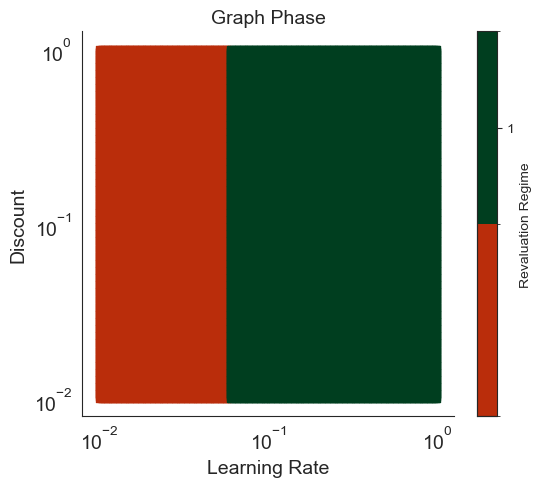

In [9]:

####### ##############################################
# Generate plot for Modes of Revaluation Scores
################ ############################## ##########################
# Discrete colormap

fontSizeSelect = 14

bins = 3   # number of bins

# labels = np.digitize(revaluation_scores, bins=np.linspace(revaluation_scores.min(), revaluation_scores.max(), bins+1)[1:-1])
labels = revaluation_scores

unique_ids = np.unique(labels)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


# custom_colors = ['#F7C59F', '#CCDDB7', '#083D77']  # custom colors for 3 bins
custom_colors = ['#BA2D0B', '#003E1F']  # custom colors for 3 bins

cmap = mcolors.ListedColormap(custom_colors)  
plt.figure(figsize=(6, 5))
sc = plt.scatter(x, y, c=labels, cmap=cmap, s=20, marker="s", norm=norm)  # square markers = pixels

cbar = plt.colorbar(sc, ticks=[-1,1])
# cbar.ax.set_yticklabels([0, 0.5, 1])  # replace [0,1,2] with custom labels
# cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
cbar.set_label("Revaluation Regime")

plt.xlabel("Learning Rate", fontsize=fontSizeSelect)

plt.xscale("log")   # make y-axis logarithmic
plt.yscale("log")   # make y-axis logarithmic


plt.ylabel("Discount", fontsize=fontSizeSelect)
plt.title("Graph Phase", fontsize=fontSizeSelect)

# ticks font size
plt.xticks(fontsize=fontSizeSelect)
plt.yticks(fontsize=fontSizeSelect)

sns.set_style("white")
sns.despine()


# add circle with centered at mean = [0.26, 0.75] and radius = 0.1
# mean_lr = 0.26
# mean_dct = 0.75
# radius = 0.1
# circle = plt.Circle((mean_lr, mean_dct), radius, color='yellow', fill=False, linewidth=2)
# plt.gca().add_patch(circle)

# savefigure to svg
plt.savefig('Figures/SGM2025_TransitionRevaluation_GraphPhase_RevaluationScores_2026.svg', format='svg', bbox_inches='tight')

plt.show()


x_phaseD = x.copy()
y_phaseD = y.copy()
labels_phaseD = labels.copy()




/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_32495/77330054.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors


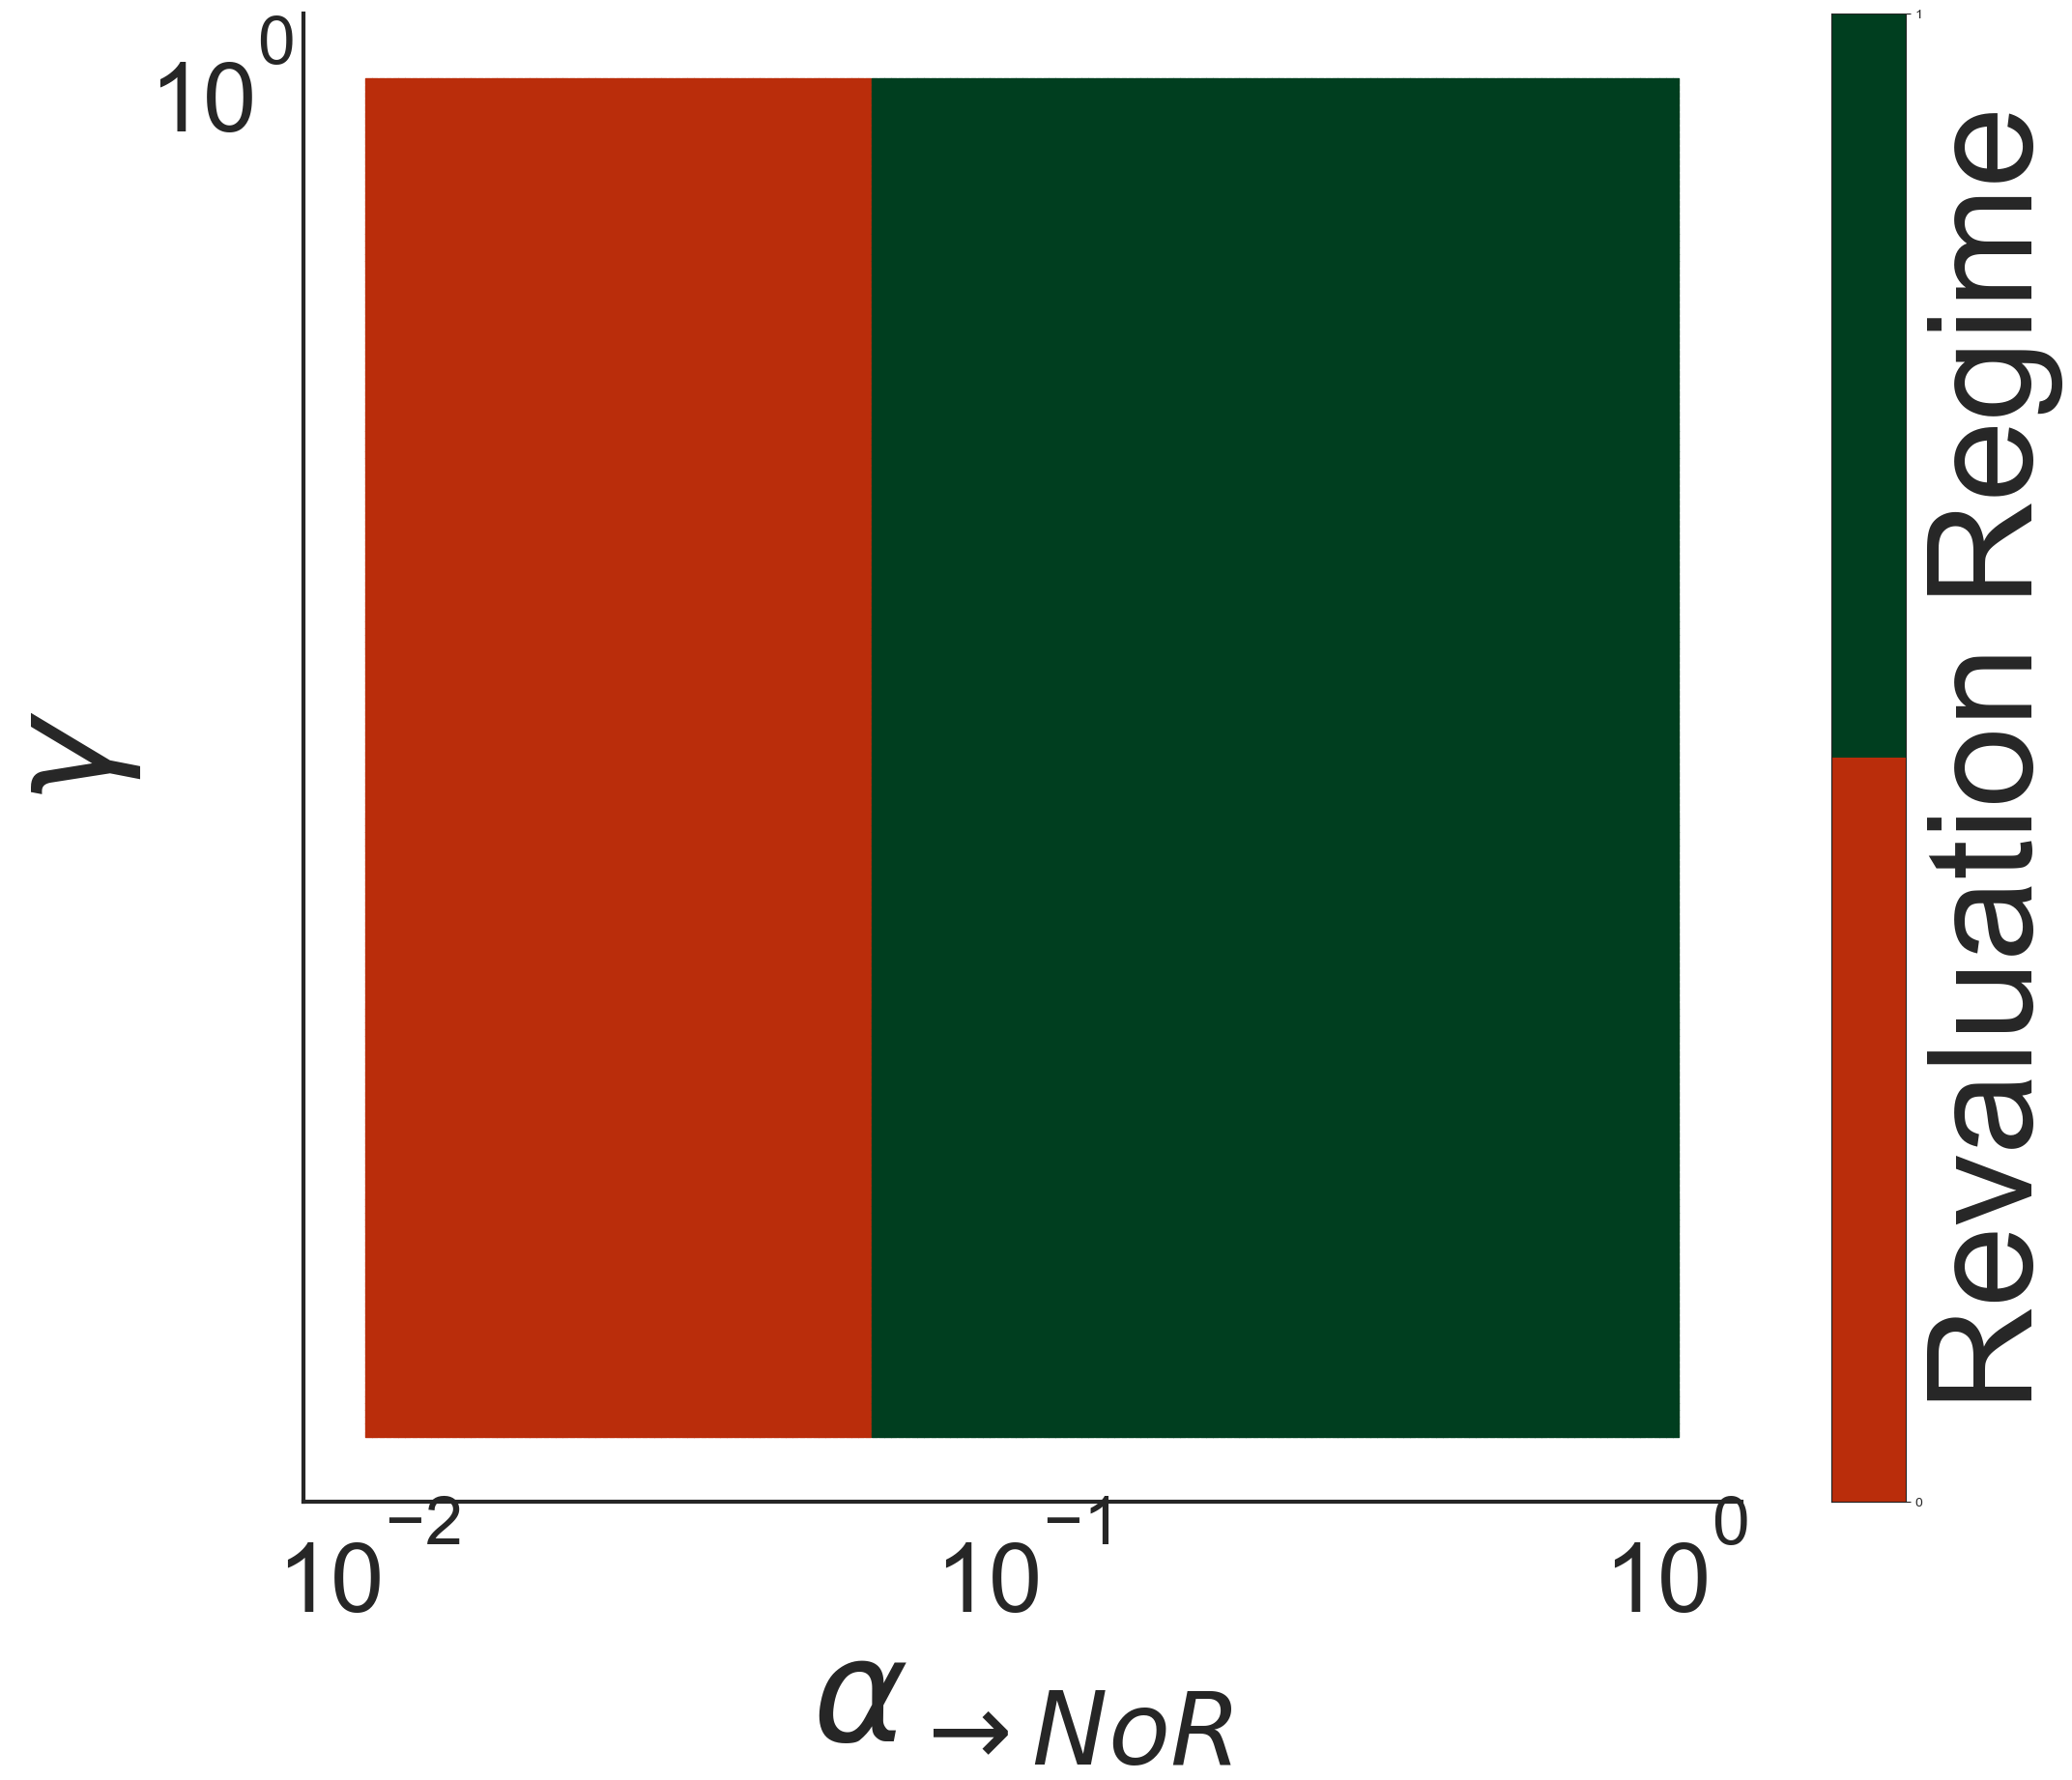

In [10]:

mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

nn = 4

x, y = zip(*iter_num)
x = np.array(x)
y = np.array(y)

fontSizeSelect = 30 *nn*3/5

bins = 3   # number of bins

fig, ax = plt.subplots(figsize=(6*nn, 5*nn))  # define figure and axis

labels = revaluation_scores


unique_ids = np.unique(labels)
n_ids = len(unique_ids)

cmap = plt.cm.get_cmap("Set1", n_ids)  # tab10 but restricted to n_ids colors
norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


custom_colors = ['#BA2D0B', '#003E1F']  # custom colors for 3 bins
cmap = mcolors.ListedColormap(custom_colors)  

sc = plt.scatter(x, y, c=labels, cmap=cmap, s=20, marker="s")  # square markers = pixels
cbar = plt.colorbar(sc, ticks=range(n_ids))


# cbar.ax.set_yticklabels([0, 1], fontsize=fontSizeSelect)  # replace [0,1,2] with custom labels
# cbar.ax.set_yticklabels(unique_ids)  # show actual idsxcvxcvxcvxcvxv instead of 0,1,2...
cbar.set_label("Revaluation Regime", fontsize=fontSizeSelect*1.5)


plt.xlabel(r'$\alpha_{\rightarrow NoR}$', fontsize=fontSizeSelect*1.5)

plt.xscale("log")   # make y-axis logarithmic
plt.yscale("log")   # make y-axis logarithmic

from matplotlib.ticker import FixedLocator

# Force EXACT y ticks only at 10^0 and 10^-0.5
ax.yaxis.set_major_locator(FixedLocator([10**0, 10**(-0.5)]))
ax.yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks
# ax.set_yticklabels(["$10^{0}$", "$10^{-0.5}$"], fontsize=fontSizeSelect)

plt.ylabel(r'$\gamma$', fontsize=fontSizeSelect*1.5)
# plt.title("Graph Phase", fontsize=fontSizeSelect)

# ticks font size
plt.xticks(fontsize=fontSizeSelect)
plt.yticks( fontsize=fontSizeSelect)

ax.tick_params(axis='both', which='major', labelsize=fontSizeSelect)
ax.tick_params(axis='both', which='minor', labelsize=fontSizeSelect )


sns.set_style("white")
sns.despine()


ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
# savefigure to svg
plt.savefig('Figures/SGM2025_TransitionRevaluation_GraphPhase_RevaluationScores_2026.svg', format='svg', bbox_inches='tight')

plt.show()

# Show triple point in the phase diagram

In [12]:
# import numpy as np
# from scipy.spatial import cKDTree
# revaluation_scores = np.array(revaluation_scores)
# labels = np.digitize(revaluation_scores, bins=np.linspace(revaluation_scores.min(), revaluation_scores.max(), bins+1)[1:-1])


# # Suppose you already have:
# # x, y = coordinate arrays (same length)
# # labels = discrete phase labels (0, 1, 2)

# points = np.column_stack((x, y))
# tree = cKDTree(points)

# # Radius for neighborhood search (tune this)
# radius = 0.005

# triple_indices = []
# triple_parameters = []
# for i, label in enumerate(labels):
#     # find neighbors within radius
#     neighbors = tree.query_ball_point(points[i], r=radius)
#     neighbor_labels = np.unique(labels[neighbors])
    
#     # triple point condition: all 3 labels appear nearby
#     if len(neighbor_labels) == 2:
#         triple_indices.append(i)
#         triple_parameters.append((x[i], y[i]))

# triple_coords = points[triple_indices]
# print("Triple point coordinates (Learning Rate, Discount):")


# plt.scatter(x, y, c=labels, cmap=cmap, s=200, marker="s")
# plt.scatter(triple_coords[:,0], triple_coords[:,1], color="black", s=100, marker="x")
# # log scale for axes
# # plt.xscale("log")
# plt.ylabel("Discount")
# plt.xlabel("Learning Rate")


Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards during relearning: [0, 0, 0, 0, 1, 10]
Given rewards during learning: [0, 0, 0, 0, 10, 1]
Given rewards

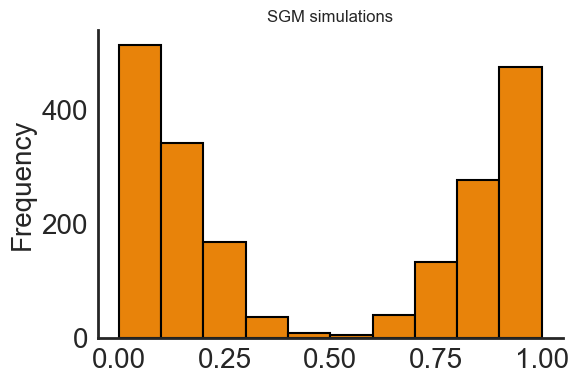

In [ ]:

graph_iter = []

revaluation_scores_distribution = []
graph_iter_after_learning = []

mean = [0.055,0.68]                      # mean vector
cov = [[.001, 0], [0, .001]]         # covariance matrix (correlation = 0.8)


params_samples = []

for i in range(2000):

    lr_x = -1
    dct_y = -1

    while (lr_x<0 or lr_x>1 )or (dct_y < 0  or dct_y > 1):
        samples = np.random.multivariate_normal(mean, cov, size=1)
    # Extract columns
        lr_x, dct_y = samples[0][0], samples[0][1]

    # # impose limits on x and y
    # if x < 0.0001 or x > 0.9999:
    #     x = np.clip(x, 0.000000, 1)
    # if y < 0.0001 or y > 0.9999:
    #     y = np.clip(y, 0.000000, 1)

    learning_rate = inv_logit(lr_x)
    threshold = inv_logit(0.70)
    discount = inv_logit(dct_y)
    # temperature = np.log(0.0000000000000001)
    # learning_rate_rew_stim = inv_logit(0.1)
    # learning_rate_norew_stim = inv_logit(0.1)
    learning_rate_rew_nostim = inv_logit(0.4)
    reward_learning_rate = inv_logit(0.9)

    n_runs = 1
    for i in range(n_runs):
        graph_list_learning, graph_list_relearning, rewards_list_learning, rewards_list_relearning, preference_after_learning, preference_after_relearning, revaluation_score, sr_list_learning, sr_list_relearning = learnCG_rewardRev(learning_rate, threshold, discount,learning_rate_rew_nostim,reward_learning_rate, transition_lists, n_episodes, added_noise = 0.15)


    # Save SR_after_learning for case 1
    SR_after_learning = sr_list_learning[-1]
    SR_after_relearning = sr_list_relearning[-1]

    graph_after_learning = graph_list_learning[-1]
    graph_after_relearning = graph_list_relearning[-1]

    # revaluation_scores = np.array(revaluation_scores)
    revaluation_scores_distribution.append(revaluation_score)

    params_samples.append([lr_x,dct_y])
    graph_iter.append(graph_after_relearning)
    graph_iter_after_learning.append(graph_after_learning)





bins = 2

labels = np.digitize(revaluation_scores_distribution, bins=np.linspace(np.min(revaluation_scores_distribution), np.max(revaluation_scores_distribution), bins+1)[1:-1])
# graphs = np.digitize(graph_iter, bins=np.linspace(np.min(graph_after_relearning), np.max(graph_after_relearning), bins+1)[1:-1])


# graph_iter.append(graph_after_relearning)
# iter_num.append((lr_i,dct_i))


fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(revaluation_scores_distribution, color="#e8830a",  edgecolor='black', linewidth=1.5)
ax.set_title('SGM simulations')
ax.set_xlabel('')
ax.set_ylabel('Frequency', fontsize=20)
## change the size the ticks size
plt.tick_params(axis='both', which='major', labelsize=20)
plt.tick_params(axis='both', which='minor', labelsize=20)
# plt.grid(True)
sns.despine()
# plt.xticks([-0.5, 0, 0.5, 1], rotation=0) 
ax.spines['bottom'].set_linewidth(2)  # Thicken the x-axis
ax.spines['left'].set_linewidth(2)    # Thicken the y-axis
# save svg figure
# plt.savefig('Figures/TransitionRevaluation_Sims_sampleSingleDistribution_SGM2025_2026.svg', format='svg', dpi=300, bbox_inches='tight')


In [14]:

# bin values of reevaluation_scores_distribution <0.25, 0.25<x<0.75, >0.75
bins_figure = [-1, 0.5, 2  ]
labels_reev= np.digitize(revaluation_scores_distribution, bins=bins_figure)
# 


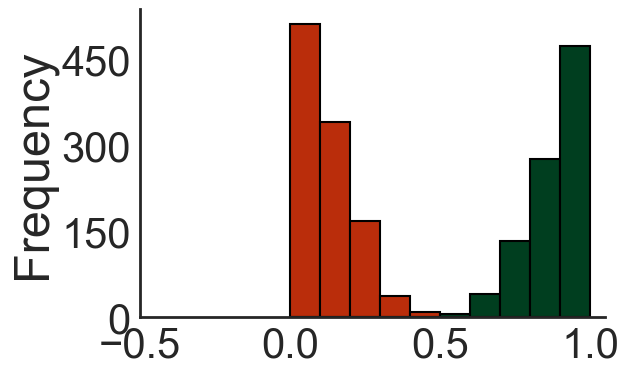

In [15]:
import matplotlib.ticker as ticker
custom_colors = ['#BA2D0B', '#003E1F']  # custom colors for 3 bins
mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
size1 = 30
size2 = 35

binsStd = np.histogram(revaluation_scores_distribution, bins=10)[1]

fig, ax = plt.subplots(figsize=(6, 4))

# if revaluation_scores > 1, set to 1
#revaluation_scores[revaluation_scores > 1] = 1
plt.hist(np.array(revaluation_scores_distribution)[labels_reev==1], bins = binsStd, range = range_hist, color = custom_colors[0], alpha = 1, label = 'Mode 1',edgecolor='black', linewidth=1.5)
plt.hist(np.array(revaluation_scores_distribution)[labels_reev==2], bins = binsStd, range = range_hist, color = custom_colors[1], alpha = 1, label = 'Mode 2',edgecolor='black', linewidth=1.5)
# plt.hist(np.array(revaluation_scores_distribution)[labels_reev==3], bins = binsStd, range = range_hist, color = custom_colors[2], alpha = 1, label = 'Mode 3',edgecolor='black', linewidth=1.5)
plt.legend
# x-axis label: Revaluation Scores
# plt.xlabel('Revaluation Scores', fontsize=20)
# y-axis label: No. of participants
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
plt.ylabel('Frequency', fontsize=size2)
# Title: Histogram of Revaluation Scores
# plt.title('Histogram of Revaluation Scores')

sns.despine()
plt.xticks([-0.5, 0, 0.5, 1], fontsize=size1, rotation=0) 
plt.yticks(fontsize=size1, rotation=0) 

ax.spines['bottom'].set_linewidth(2)  # Thicken the x-axis
ax.spines['left'].set_linewidth(2)    # Thicken the y-axis
# save svg figure
plt.savefig('Figures/Rewardevaluation_Sims_sampleSingleDistribution_MultiColor_SGM2025_2026.svg', format='svg', dpi=300, bbox_inches='tight')


plt.show()

In [16]:
# # index where graph iters have nan values
# nan_indices = [i for i, g in enumerate(graph_iter) if np.isnan(g).any()]

# params_samples_selected = [p for i, p in enumerate(params_samples) if i not in nan_indices]
# graph_iter_selcted = [g for i, g in enumerate(graph_iter) if i not in nan_indices]


# hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter_selcted]


# # Count frequencies
# counts = Counter(hashable_arrays)

# # Build identity vector
# ids = []
# for mat in graph_iter:
#     for i, uniq in enumerate(list(counts.keys())):
#         if np.array_equal(mat, uniq):   # compare matrices
#             ids.append(i)  # or i+1 if you want 1-based index
#             break

# # Example data
# x, y = zip(*params_samples_selected)
# x = np.array(x)
# y = np.array(y)
# ids = np.array(ids)

# # Discrete colormap

# ### Generate plot for Graph phase diagram

# unique_ids = np.unique(ids)
# n_ids = len(unique_ids)

# cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
# norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


# plt.figure(figsize=(6, 5))
# sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

# cbar = plt.colorbar(sc, ticks=range(n_ids))
# cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
# cbar.set_label("Graph")

# plt.xlabel("Learning Rate")
# plt.xscale("log")   # make y-axis logarithmic
# plt.yscale("log")   # make y-axis logarithmic

# plt.ylabel("Discount")
# plt.title("Graph Phase after Relearning")

# sns.set_style("white")
# sns.despine()

# plt.show()


In [17]:

# n = len(counts)
# ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
# nrows = int(np.ceil(n / ncols))

# array_unique = list(counts.keys())

# fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# # Flatten axes for easy indexing
# axes = axes.flatten()

# for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

#     mat = array_unique[iii]
#     f = iii
#     node_sizes = 800

#     # plot the graph using nx.digraph
#     G = nx.MultiDiGraph()
#     G.add_nodes_from(states)
#     connectionstyle1 = 'arc3,rad=-0.4'
#     connectionstyle2 = 'arc3,rad=-0.4'
#     edgelist1 = []
#     edgelist2 = []
#     for i in range(len(states)):
#         for j in range(len(states)):
#             if mat[i][j] == 1:
#                 edgelist1.append((states[i],states[j]))

#     nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
#     # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


#     ax.set_xlim(-0.5, 2.5)
#     ax.set_ylim(-0.5, 1.5)

#     # save figure to svg
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

#     ax.set_title("Graph " + str(f), fontsize=20)
    
#     #     Hide any unused subplots if counts doesn't fill the grid
#     for ax in axes[n:]:
#         ax.axis("off")

# plt.suptitle("After Re-learning", fontsize=24)
# plt.show()


In [18]:

# # index where graph iters have nan values
# nan_indices = [i for i, g in enumerate(graph_iter_after_learning) if np.isnan(g).any()]

# params_samples_selected = [p for i, p in enumerate(params_samples) if i not in nan_indices]
# graph_iter_selected = [g for i, g in enumerate(graph_iter_after_learning) if i not in nan_indices]


# hashable_arrays = [tuple(map(tuple, arr)) for arr in graph_iter_selected]


# # Count frequencies
# counts = Counter(hashable_arrays)

# # Build identity vector
# ids = []
# for mat in graph_iter_after_learning:
#     for i, uniq in enumerate(list(counts.keys())):
#         if np.array_equal(mat, uniq):   # compare matrices
#             ids.append(i)  # or i+1 if you want 1-based index
#             break

# # Example data
# x, y = zip(*params_samples_selected)
# x = np.array(x)
# y = np.array(y)
# ids = np.array(ids)

# # Discrete colormap

# ### Generate plot for Graph phase diagram

# unique_ids = np.unique(ids)
# n_ids = len(unique_ids)

# cmap = plt.cm.get_cmap("tab10", n_ids)  # tab10 but restricted to n_ids colors
# norm = mcolors.BoundaryNorm(boundaries=np.arange(n_ids+1)-0.5, ncolors=n_ids)


# plt.figure(figsize=(6, 5))
# sc = plt.scatter(x, y, c=ids, cmap=cmap, s=200, marker="s", norm=norm)  # square markers = pixels

# cbar = plt.colorbar(sc, ticks=range(n_ids))
# cbar.ax.set_yticklabels(unique_ids)  # show actual ids instead of 0,1,2...
# cbar.set_label("Graph")

# plt.xlabel("Learning Rate")
# plt.xscale("log")   # make y-axis logarithmic
# plt.ylabel("Discount")
# plt.title("Graph Phase After Learning")

# sns.set_style("white")
# sns.despine()

# plt.show()


In [19]:

# n = len(counts)
# ncols = int(np.ceil(np.sqrt(n)))  # arrange in roughly square grid
# nrows = int(np.ceil(n / ncols))

# array_unique = list(counts.keys())

# fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))

# # Flatten axes for easy indexing
# axes = axes.flatten()

# for iii, (graph_i_show, ax) in enumerate(zip(counts.keys(), axes)):

#     mat = array_unique[iii]
#     f = iii
#     node_sizes = 800

#     # plot the graph using nx.digraph
#     G = nx.MultiDiGraph()
#     G.add_nodes_from(states)
#     connectionstyle1 = 'arc3,rad=-0.4'
#     connectionstyle2 = 'arc3,rad=-0.4'
#     edgelist1 = []
#     edgelist2 = []
#     for i in range(len(states)):
#         for j in range(len(states)):
#             if mat[i][j] == 1:
#                 edgelist1.append((states[i],states[j]))

#     nx.draw(G, pos,ax=ax, with_labels=True, connectionstyle=connectionstyle1, edgelist = edgelist1, edge_color='black',edgecolors='black',node_size=node_sizes,  linewidths =2,  node_shape="o",  node_color= "#ffffff",    arrowsize=10, width=4)  # default is ~10)
#     # ax.text(0.5, .9, f"Graph {f+1}", ha='center', va='center', transform=ax.transAxes, fontsize=30)


#     ax.set_xlim(-0.5, 2.5)
#     ax.set_ylim(-0.5, 1.5)

#     # save figure to svg
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_2026.svg", format='svg', bbox_inches='tight')
#     # plt.savefig(f"FiguresGraph_Human2Step/HistogramGraph_Human2Step_{f}_colorEdge.png", format='png', bbox_inches='tight', dpi=400)

#     ax.set_title("Graph " + str(f), fontsize=20)
    
#     #     Hide any unused subplots if counts doesn't fill the grid
#     for ax in axes[n:]:
#         ax.axis("off")

# plt.suptitle("After Learning", fontsize=24)
# plt.show()
